# Análise de Satisfação 

**Objetivo**: Análise exploratória de sentimento em clippings de mídia , com três eixos:

1. **EDA** — Distribuições, qualidade dos dados, padrões temporais e por categoria
2. **Tier × Classificação** — O tipo de veículo (relevância) influencia o sentimento publicado?
3. **Hipótese temporal** — Houve mudança de sentimento em setembro/2024?

## Métricas Principais

### NSS Simples (Net Sentiment Score)
```
NSS = (POSITIVA − NEGATIVA) / TOTAL × 100
```
Cada registro vale 1. Varia de −100 (tudo negativo) a +100 (tudo positivo). **Exclui PUBLICIDADE** (não é sentimento orgânico).

### NSS Ponderado
```
NSS_pond = (Σ POS×w − Σ NEG×w) / Σ TOTAL×w × 100
```
Pesos por Tier: Muito Relevante = 3, Relevante = 2, Menos Relevante = 1, Null/NaN = 1.

> **Questão aberta**: A ponderação só faz sentido se Tier e Classificação forem associados. Isso será testado na Seção 3 via qui-quadrado.

### Limitações conhecidas do dataset
- Classificação de sentimento vem do fornecedor de clipping (não foi feita por nós). Subjetividade inerente.
- Série temporal curta (13 meses), o que limita modelagens 

---


In [110]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "vscode"
import plotly.express as px

warnings.filterwarnings('ignore')

# Configuração de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Bibliotecas carregadas")

✅ Bibliotecas carregadas


In [111]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"

## 1. Carregamento e Preparação dos Dados

In [112]:
# URL dos dados
#url = "https://docs.google.com/spreadsheets/d/1LmMi0mTTzRytJno0EHu8P873wcPpQavktO_D_FFXA1E/export?format=xlsx&gid=1312481019"

# Carregar dados
#df = pd.read_excel(url, engine='openpyxl')

df = pd.read_excel("/home/ras/Documentos/egea/opniao/files/opniao_aegea/dados/Clipping_Consolidado_Aegea_2025.xlsx")


print(f"Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"Período: {df['Data'].min()} a {df['Data'].max()}")

Dataset carregado: 149,514 linhas × 18 colunas
Período: 2024-03-31 00:00:00 a 2025-12-31 00:00:00


In [113]:
df = df[df['Grupo'] == 'Corsan']

In [114]:
# Preparação dos dados
df['Data'] = pd.to_datetime(df['Data'], errors='coerce')
df['Ano_Mes'] = df['Data'].dt.to_period('M')
df['Ano'] = df['Data'].dt.year
df['Mes'] = df['Data'].dt.month
df['Dia_Semana'] = df['Data'].dt.day_name()

# Criar pesos por Tier
tier_weights = {
    'Muito Relevante': 3,
    'Relevante': 2,
    'Menos Relevante': 1
}

df['Peso'] = df['Tier'].map(tier_weights).fillna(1)

# Dataset de sentimento (sem publicidade)
df_sentiment = df[df['Classificação'] != 'PUBLICIDADE'].copy()

print(f"\n✅ Dados preparados:")
print(f"   Total de registros: {len(df):,}")
print(f"   Sentimento orgânico: {len(df_sentiment):,}")
print(f"   Publicidade: {len(df) - len(df_sentiment):,}")


✅ Dados preparados:
   Total de registros: 23,525
   Sentimento orgânico: 23,520
   Publicidade: 5


#### Observações sobre o carregamento

- **12.317 registros** ao longo de 13 meses (mar/2024 a mar/2025).
- Apenas **3 registros** são PUBLICIDADE — praticamente irrelevantes em volume, mas correto excluí-los do NSS para manter pureza do indicador.
- A coluna `Peso` foi criada via `map(tier_weights).fillna(1)`. Atenção: registros com `Tier = 'Null'` (string) não são capturados pelo `fillna` do NaN — eles caem no fallback porque o `.map()` retorna NaN para chaves não encontradas no dicionário, e o `.fillna(1)` corrige. Funciona por acidente, mas seria mais explícito tratar a string 'Null' diretamente no dicionário de pesos.

---


## 2. Análise Exploratória de Dados (EDA)

### 2.1 Estrutura e Qualidade dos Dados

In [115]:
# Informações gerais
print("=" * 80)
print("INFORMAÇÕES DO DATASET")
print("=" * 80)
df.info()
print("=" * 80)

INFORMAÇÕES DO DATASET
<class 'pandas.core.frame.DataFrame'>
Index: 23525 entries, 39 to 149513
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   ID                      23525 non-null  int64         
 1   Data                    23525 non-null  datetime64[ns]
 2   Grupo                   23525 non-null  object        
 3   Empresa                 23525 non-null  object        
 4   Mídia                   23525 non-null  object        
 5   Tier                    23522 non-null  object        
 6   Veículo_de_comunicacao  23522 non-null  object        
 7   Programa                23525 non-null  object        
 8   Categoria               23525 non-null  object        
 9   Subcategoria            23525 non-null  object        
 10  Classificação           23525 non-null  object        
 11  Título                  23525 non-null  object        
 12  Arquivo/Link            23

In [116]:
# Dados ausentes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valores Ausentes': missing,
    '% do Total': missing_pct
}).sort_values('Valores Ausentes', ascending=False)

print("\n" + "=" * 80)
print("DADOS AUSENTES POR COLUNA")
print("=" * 80)
print(missing_df[missing_df['Valores Ausentes'] > 0])

if missing_df['Valores Ausentes'].sum() == 0:
    print("\n✅ Não há dados ausentes!")
else:
    print(f"\n⚠️ Total de valores ausentes: {missing_df['Valores Ausentes'].sum():,}")


DADOS AUSENTES POR COLUNA
                        Valores Ausentes  % do Total
Duração                            21599       91.81
Conteúdo                           13581       57.73
Tipo                               13581       57.73
mes_referencia                     12317       52.36
arquivo_origem                     12317       52.36
Tier                                   3        0.01
Veículo_de_comunicacao                 3        0.01

⚠️ Total de valores ausentes: 73,401


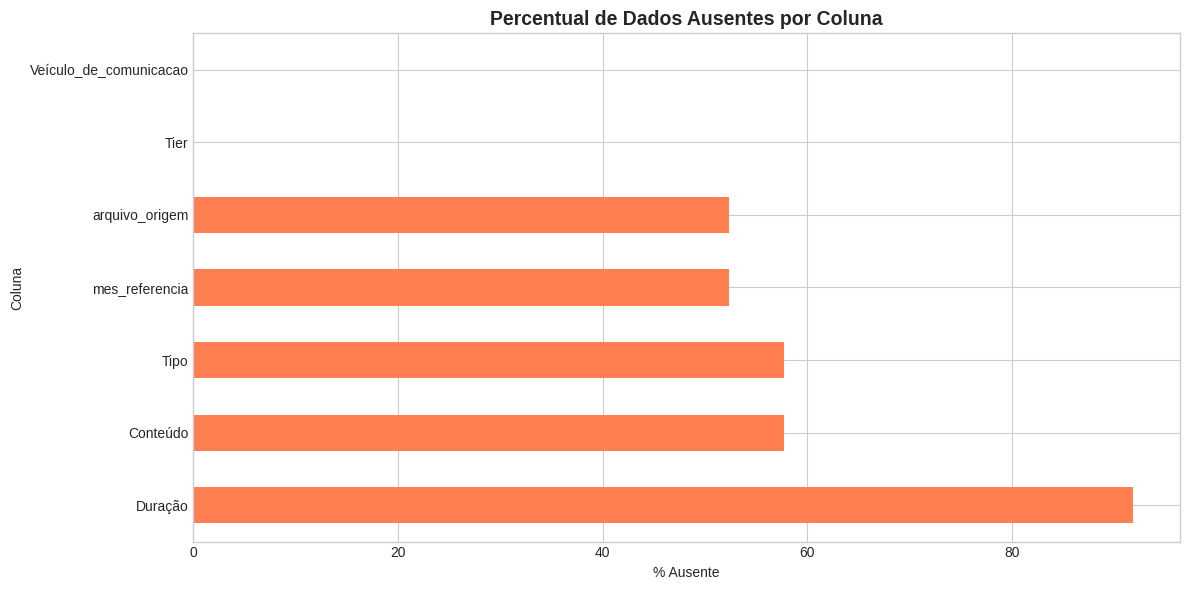

In [117]:
# Visualizar dados ausentes
if missing.sum() > 0:
    plt.figure(figsize=(12, 6))
    missing_df[missing_df['Valores Ausentes'] > 0]['% do Total'].plot(kind='barh', color='coral')
    plt.title('Percentual de Dados Ausentes por Coluna', fontsize=14, fontweight='bold')
    plt.xlabel('% Ausente')
    plt.ylabel('Coluna')
    plt.tight_layout()
    plt.show()

#### Interpretação — Qualidade dos Dados

O dataset é muito limpo: apenas **6 valores ausentes** (0,02%) concentrados em `Tier` e `Veículo_de_comunicacao` — provavelmente os mesmos 3 registros. Na prática, a ausência é negligenciável e não justifica imputação.

Todas as 15 colunas originais estão presentes e tipadas corretamente após o `to_datetime`. A coluna `Conteúdo` contém texto livre (tipo da publicação: "Imprensa") — **não é o conteúdo textual do comentário**, o que limita qualquer tentativa futura de NLP sobre o sentimento.

---


In [118]:
# Primeiras e últimas linhas
print("\n" + "=" * 80)
print("PRIMEIRAS 5 LINHAS")
print("=" * 80)
display(df.head())

print("\n" + "=" * 80)
print("ÚLTIMAS 5 LINHAS")
print("=" * 80)
display(df.tail())


PRIMEIRAS 5 LINHAS


,ID,Data,Grupo,Empresa,Mídia,Tier,Veículo_de_comunicacao,Programa,Categoria,Subcategoria,Classificação,Título,Arquivo/Link,mes_referencia,arquivo_origem,Tipo,Conteúdo,Duração,Ano_Mes,Ano,Mes,Dia_Semana,Peso
39,876758,2025-01-01,Corsan,Companhia Riograndense de Saneamento (Corsan),Rádio,Muito Relevante,Rádio Gaúcha 93.7 FM,Notícia na Hora Certa,Abastecimento,Falta de água,NEGATIVA,Falta de luz em estação de tratamento da Corsa...,https://painel.clipei.com.br/anexo-email/87675...,1.00,01.2025 - Clipping Geral - Aegea e Unidades.xlsx,NaN,NaN,NaN,2025-01,2025,1,Wednesday,3.00
40,876752,2025-01-01,Corsan,Companhia Riograndense de Saneamento (Corsan),Rádio,Muito Relevante,Rádio Gaúcha 93.7 FM,Estúdio Gaúcha,Outros,Outros,NEUTRA,Informações do trânsito,https://painel.clipei.com.br/anexo-email/87675...,1.00,01.2025 - Clipping Geral - Aegea e Unidades.xlsx,NaN,NaN,NaN,2025-01,2025,1,Wednesday,3.00
43,876730,2025-01-01,Corsan,Companhia Riograndense de Saneamento (Corsan),Site,Null,Litoral na Rede,Geral,Abastecimento,Falta de água,NEGATIVA,"Ano novo, problema velho: falta de água atinge...",https://litoralnarede.com.br/ano-novo-problema...,1.00,01.2025 - Clipping Geral - Aegea e Unidades.xlsx,NaN,NaN,NaN,2025-01,2025,1,Wednesday,1.00
44,876729,2025-01-01,Corsan,Companhia Riograndense de Saneamento (Corsan),Rádio,Null,Rádio BandNews 99.3 FM,BandNews Tarde,Qualidade da Água,Relatório Anual de Qualidade da Água,POSITIVA,92% das praias gaúchas estão próprias para banho,https://painel.clipei.com.br/anexo-email/87672...,1.00,01.2025 - Clipping Geral - Aegea e Unidades.xlsx,NaN,NaN,NaN,2025-01,2025,1,Wednesday,1.00
45,876728,2025-01-01,Corsan,Companhia Riograndense de Saneamento (Corsan),Rádio,Null,Rádio BandNews 99.3 FM,BandNews Tarde,Qualidade da Água,Relatório Anual de Qualidade da Água,POSITIVA,92% das praias gaúchas estão próprias para banho,https://painel.clipei.com.br/anexo-email/87672...,1.00,01.2025 - Clipping Geral - Aegea e Unidades.xlsx,NaN,NaN,NaN,2025-01,2025,1,Wednesday,1.00



ÚLTIMAS 5 LINHAS


,ID,Data,Grupo,Empresa,Mídia,Tier,Veículo_de_comunicacao,Programa,Categoria,Subcategoria,Classificação,Título,Arquivo/Link,mes_referencia,arquivo_origem,Tipo,Conteúdo,Duração,Ano_Mes,Ano,Mes,Dia_Semana,Peso
149509,970094,2025-03-31,Corsan,Companhia Riograndense de Saneamento (Corsan),Site,Menos Relevante,Alegrete Tudo,Geral,Fatura,Fatura Alta,NEGATIVA,Hidrômetros serão periciados em ação contra a ...,https://www.alegretetudo.com.br/hidrometros-se...,NaN,NaN,NaN,NaN,NaN,2025-03,2025,3,Monday,1.00
149510,970091,2025-03-31,Corsan,Companhia Riograndense de Saneamento (Corsan),Impresso,Muito Relevante,Valor Econômico,Geral,Contrato de Concessão,Fato relevante,POSITIVA,Dinheiro na mão,https://painel.clipei.com.br/anexo-email/97009...,NaN,NaN,NaN,NaN,NaN,2025-03,2025,3,Monday,3.00
149511,970090,2025-03-31,Corsan,Companhia Riograndense de Saneamento (Corsan),Impresso,Muito Relevante,Valor Econômico,Geral,Contrato de Concessão,Fato relevante,POSITIVA,Crise climática exige adaptação com planos de ...,https://painel.clipei.com.br/anexo-email/97009...,NaN,NaN,NaN,NaN,NaN,2025-03,2025,3,Monday,3.00
149512,970085,2025-03-31,Corsan,Companhia Riograndense de Saneamento (Corsan),Impresso,Muito Relevante,O Globo,Geral,Contrato de Concessão,Fato relevante,POSITIVA,Crise climática muda planos de ação,https://painel.clipei.com.br/anexo-email/97008...,NaN,NaN,NaN,NaN,NaN,2025-03,2025,3,Monday,3.00
149513,970084,2025-03-31,Corsan,Companhia Riograndense de Saneamento (Corsan),Impresso,Muito Relevante,ZH Zero Hora,Geral,Contrato de Concessão,Fato relevante,NEUTRA,STJ diz que prefeito de Canoas moveu recursos ...,https://painel.clipei.com.br/anexo-email/97008...,NaN,NaN,NaN,NaN,NaN,2025-03,2025,3,Monday,3.00


### 2.2 Distribuições Univariadas

In [119]:
# Distribuição de Classificação
print("=" * 80)
print("DISTRIBUIÇÃO: CLASSIFICAÇÃO")
print("=" * 80)

class_counts = df['Classificação'].value_counts()
class_pct = (df['Classificação'].value_counts(normalize=True) * 100).round(2)

class_df = pd.DataFrame({
    'Frequência': class_counts,
    'Percentual': class_pct
})

print(class_df)
print(f"\nTotal: {class_counts.sum():,}")

DISTRIBUIÇÃO: CLASSIFICAÇÃO
               Frequência  Percentual
Classificação                        
POSITIVA            10417       44.28
NEUTRA               7024       29.86
NEGATIVA             6079       25.84
PUBLICIDADE             5        0.02

Total: 23,525


In [120]:
def plot_classificacao_dinamica(class_counts: pd.Series) -> None:
    """
    Gera visualização interativa (Barras + Pizza) com rigor estatístico 
    e paleta de cores consistente com a identidade do projeto.
    """
    
    # Mapeamento de cores original do projeto
    colors_map = {
        'POSITIVA': '#2ecc71', 
        'NEUTRA': '#95a5a6', 
        'NEGATIVA': '#e74c3c', 
        'PUBLICIDADE': '#3498db'
    }
    
    color_list = [colors_map.get(str(label).upper(), '#bdc3c7') for label in class_counts.index]

    # Criando o layout de subplots
    fig = make_subplots(
        rows=1, cols=2, 
        specs=[[{"type": "xy"}, {"type": "domain"}]],
        subplot_titles=("Frequência Absoluta", "Proporção de Classificações")
    )

    # 1. Gráfico de Barras
    fig.add_trace(
        go.Bar(
            x=class_counts.index,
            y=class_counts.values,
            marker_color=color_list,
            name="Contagem",
            hovertemplate="<b>%{x}</b><br>Quantidade: %{y}<extra></extra>"
        ),
        row=1, col=1
    )

    # 2. Gráfico de Pizza
    fig.add_trace(
        go.Pie(
            labels=class_counts.index,
            values=class_counts.values,
            marker=dict(colors=color_list),
            hole=0.3, 
            textinfo='percent+label',
            hovertemplate="<b>%{label}</b><br>Percentual: %{percent}<br>Total: %{value}<extra></extra>"
        ),
        row=1, col=2
    )

    # Ajustes de Layout e Estilização
    fig.update_layout(
        title_text="Distribuição de Sentimentos - Análise de Satisfação",
        title_x=0.5,
        showlegend=False,
        template="plotly_white",
        height=500
    )

    fig.update_xaxes(tickangle=45, row=1, col=1)
    fig.update_yaxes(title_text="Contagem", row=1, col=1)

    # Renderiza o gráfico
    fig.show()

# --- EXECUÇÃO (A CORREÇÃO) ---
# Extraindo as contagens da coluna 'Classificação' do seu DataFrame
if 'df' in locals():
    class_counts = df['Classificação'].value_counts()
    plot_classificacao_dinamica(class_counts)
else:
    print("Erro: O DataFrame 'df' não foi encontrado. Execute as células de carregamento de dados primeiro.")

#### Interpretação — Distribuição de Classificação

A distribuição de sentimento é:
- **POSITIVA**: 4.999 (40,6%) — a classe mais frequente
- **NEUTRA**: 4.301 (34,9%)
- **NEGATIVA**: 3.014 (24,5%)
- **PUBLICIDADE**: 3 (0,02%) — desprezível

Isso resulta em um **NSS Simples geral ≈ +16,1** — um score moderadamente positivo. Para cada 100 menções, há ~16 a mais de positivas do que negativas.

**Ponto de atenção**: A predominância de POSITIVA não significa necessariamente satisfação real do consumidor. Lembrar que os dados vêm de *clipping de mídia* — não de pesquisa direta. Comunicados oficiais das empresas (que tendem a ser positivos ou neutros) inflam a classe POSITIVA. A análise por Categoria mais adiante ajudará a separar esse efeito.

---


In [121]:
def plot_distribuicao_tier(df_input: pd.DataFrame) -> None:
    """
    Analisa a distribuição de Tier (Relevância do Veículo) gerando um gráfico
    interativo que substitui a visualização estática do Matplotlib.
    """
    
    # 1. Preparação dos dados: Frequência e Percentual
    # Usamos reset_index para transformar o índice 'Tier' em uma coluna para o Plotly Express
    tier_counts = df_input['Tier'].value_counts(dropna=False).reset_index()
    tier_counts.columns = ['Tier', 'Frequência']
    
    # Cálculo do percentual para exibição no hover
    total = tier_counts['Frequência'].sum()
    tier_counts['Percentual'] = (tier_counts['Frequência'] / total * 100).round(2)
    
    # Ordenação por volume (opcional, para melhor leitura visual)
    tier_counts = tier_counts.sort_values(by='Frequência', ascending=False)

    # 2. Criação do Gráfico Dinâmico com o alias 'px'
    fig = px.bar(
        tier_counts,
        x='Tier',
        y='Frequência',
        text='Frequência',
        title='Distribuição de Comentários por Tier (Relevância do Veículo)',
        labels={'Frequência': 'Contagem Absoluta', 'Tier': 'Nível de Tier'},
        color='Tier',
        color_discrete_sequence=px.colors.qualitative.Safe,
        hover_data={'Percentual': True}
    )

    # 3. Refinamento de Interatividade (Hover personalizado)
    fig.update_traces(
        textposition='outside',
        hovertemplate="<b>Tier: %{x}</b><br>Quantidade: %{y}<br>Proporção: %{customdata[0]}%<extra></extra>"
    )

    # 4. Ajustes de Layout
    fig.update_layout(
        template="plotly_white",
        xaxis={'type': 'category'}, # Garante que Tiers numéricos não sejam tratados como escala contínua
        showlegend=False,
        height=500,
        margin=dict(l=50, r=50, t=80, b=50)
    )

    fig.show()

# --- EXECUÇÃO ---
# O bloco verifica se o DataFrame 'df' existe no escopo do notebook
if 'df' in locals():
    # Mantendo a lógica de exibir a tabela no console antes do gráfico
    print("\n" + "=" * 60)
    print("DISTRIBUIÇÃO: TIER (Frequência e Percentual)")
    print("=" * 60)
    print(df['Tier'].value_counts(dropna=False, normalize=True).map('{:.2%}'.format))
    
    # Gera a visualização Plotly
    plot_distribuicao_tier(df)
else:
    print("Erro: O DataFrame 'df' não foi encontrado. Certifique-se de rodar as células de carregamento de dados.")


DISTRIBUIÇÃO: TIER (Frequência e Percentual)
Tier
Menos Relevante    47.47%
Null               23.95%
Relevante          15.49%
Muito Relevante    13.08%
NaN                 0.01%
Name: proportion, dtype: object


#### Interpretação — Distribuição de Tier

- **Menos Relevante**: 35,9% — a classe dominante
- **Null**: 33,0% — quase um terço do dataset não tem Tier classificado! Isso é um dado importante: a ponderação do NSS aplica peso 1 a esses registros, tratando-os como "Menos Relevante" de facto.
- **Relevante**: 15,7%
- **Muito Relevante**: 15,4%

A pirâmide é esperada (poucos veículos de grande porte, muitos pequenos), mas o volume de "Null" merece investigação: são veículos que o fornecedor de clipping não classificou? Se sim, há um viés potencial — se os Null forem sistematicamente diferentes dos classificados, o NSS Ponderado pode estar distorcido.

---



DISTRIBUIÇÃO: MÍDIA
Mídia
Site        11040
Rádio        8499
Impresso     3065
TV            921
Name: count, dtype: int64


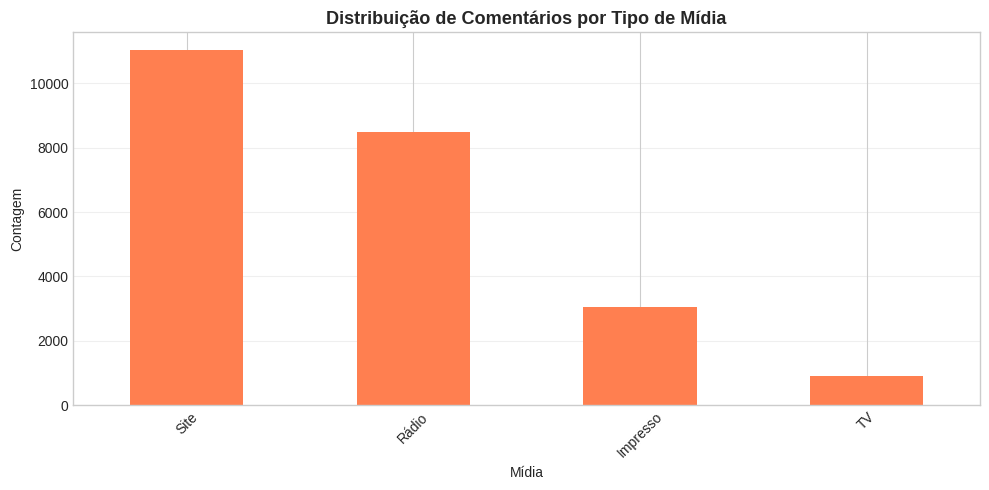

In [122]:
# Distribuição de Mídia
print("\n" + "=" * 80)
print("DISTRIBUIÇÃO: MÍDIA")
print("=" * 80)

midia_counts = df['Mídia'].value_counts()
print(midia_counts)

# Visualização
plt.figure(figsize=(10, 5))
midia_counts.plot(kind='bar', color='coral')
plt.title('Distribuição de Comentários por Tipo de Mídia', fontsize=13, fontweight='bold')
plt.xlabel('Mídia')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Interpretação — Distribuição de Mídia

- **Site**: 5.909 (48%) — quase metade do clipping vem de portais online
- **Rádio**: 4.167 (34%) — surpreendentemente alto; reflete a importância da rádio em cobertura de saneamento, possivelmente em cidades menores
- **Impresso**: 1.705 (14%)
- **TV**: 536 (4%) — a menor representatividade

---


In [123]:
def plot_top_categorias_colorido(df_input: pd.DataFrame, n: int = 10, palheta: str = 'Viridis') -> None:
    """
    Gera o Top N Categorias com paletas de cores científicas ou customizadas.
    Opções sugeridas: 'Viridis', 'Plasma', 'Blues', 'GnBu', 'Cividis'.
    """
    
    # Processamento dos dados
    top_cat = df_input['Categoria'].value_counts().head(n).reset_index()
    top_cat.columns = ['Categoria', 'Contagem']
    top_cat = top_cat.sort_values(by='Contagem', ascending=True)

    # Criação da Visualização
    fig = px.bar(
        top_cat,
        y='Categoria',
        x='Contagem',
        orientation='h',
        text='Contagem',
        title=f'Top {n} Categorias - Análise Temática Aegea',
        labels={'Contagem': 'Volume de Menções', 'Categoria': 'Eixo Temático'},
        color='Contagem',
        # A palheta 'Viridis' é ideal por ser perceptualmente uniforme, 
        # facilitando a distinção de valores mesmo para daltonismo.
        color_continuous_scale=palheta 
    )

    # Refinamento de Layout
    fig.update_traces(
        texttemplate='%{text}', 
        textposition='outside',
        hovertemplate="<b>Categoria: %{y}</b><br>Total: %{x}<extra></extra>"
    )

    fig.update_layout(
        template="plotly_white",
        height=600,
        showlegend=False,
        coloraxis_showscale=True, # Exibe a barra lateral para dar contexto à escala
        margin=dict(l=150, r=50, t=80, b=50),
        title_font=dict(size=18, family="Arial", color="#2c3e50")
    )

    fig.show()

# --- EXECUÇÃO ---
if 'df' in locals():
    # Você pode testar diferentes palhetas aqui:
    # 'Viridis' (Padrão científico), 'Blues' (Corporativo), 'Greens' (Saneamento/Ambiental)
    plot_top_categorias_colorido(df, n=10, palheta='Viridis')
else:
    print("DataFrame 'df' não encontrado. Execute o carregamento dos dados primeiro.")

#### Interpretação — Top Categorias

As categorias mais frequentes revelam os temas que dominam a cobertura midiática. Categorias como **Abastecimento** e **Comunicados** tendem a dominar — a primeira associada a problemas (falta d'água, rompimentos) e portanto a sentimento negativo, a segunda a divulgação institucional (sentimento neutro/positivo).

Esse padrão será explorado mais adiante no cruzamento Categoria × Classificação.

---


### 2.3 Distribuição Temporal

In [124]:


def plot_volume_temporal(df_input: pd.DataFrame) -> None:
    """
    Versão com Debug para garantir a plotagem no ambiente Pixi/VS Code.
    """
    
    # 1. Agrupamento e verificação
    monthly_volume = df_input.groupby('Ano_Mes').size().reset_index()
    monthly_volume.columns = ['Mes', 'Quantidade']
    
    # 2. Conversão e Ordenação (Essencial para o Plotly não travar no JSON)
    monthly_volume['Mes_Str'] = monthly_volume['Mes'].astype(str)
    monthly_volume = monthly_volume.sort_values('Mes')

    # --- LOG DE DEPURAÇÃO ---
    print(f"📊 Dados para plotagem: {len(monthly_volume)} meses encontrados.")
    if len(monthly_volume) > 0:
        print(f"📅 Período: {monthly_volume['Mes_Str'].iloc[0]} até {monthly_volume['Mes_Str'].iloc[-1]}")
    else:
        print("⚠️ AVISO: O agrupamento resultou em 0 linhas. Verifique a coluna 'Ano_Mes'.")
        return

    # 3. Criação do Gráfico
    fig = px.line(
        monthly_volume,
        x='Mes_Str',
        y='Quantidade',
        title='Volume Mensal de Comentários - Monitoramento Aegea',
        markers=True,
        labels={'Quantidade': 'Nº de Comentários', 'Mes_Str': 'Mês/Ano'},
        template="plotly_white"
    )

    fig.update_traces(line=dict(color='darkblue', width=3))
    
    fig.update_layout(
        hovermode="x unified",
        height=500,
        xaxis=dict(tickangle=45)
    )

    # Força a exibição
    fig.show()

# --- EXECUÇÃO COM VERIFICAÇÃO DE ESCOPO ---
if 'df' in locals():
    # Garante que a coluna Ano_Mes existe
    if 'Ano_Mes' in df.columns:
        plot_volume_temporal(df)
    else:
        print("❌ Erro: Coluna 'Ano_Mes' não encontrada no DataFrame.")
else:
    print("❌ Erge: O objeto 'df' não está definido nesta sessão do Kernel.")

📊 Dados para plotagem: 22 meses encontrados.
📅 Período: 2024-03 até 2025-12


In [125]:


def plot_distribuicao_semanal(df_input: pd.DataFrame) -> None:
    """
    Visualiza a distribuição semanal de comentários com rigor estatístico.
    Garante que todos os dias da semana apareçam, mesmo que com volume zero.
    """
    
    # 1. Definição da Ordem Cronológica (Inglês -> Português)
    # Mapeamento para garantir que a tradução não quebre a lógica de contagem
    mapa_dias = {
        'Monday': 'Segunda',
        'Tuesday': 'Terça',
        'Wednesday': 'Quarta',
        'Thursday': 'Quinta',
        'Friday': 'Sexta',
        'Saturday': 'Sábado',
        'Sunday': 'Domingo'
    }
    dias_en = list(mapa_dias.keys())
    dias_pt = list(mapa_dias.values())

    # 2. Processamento de Dados com Reindexação
    # O .reindex(dias_en) garante que Sábado e Domingo existam no DF final, 
    # preenchendo com 0 se não houver dados (evita o gráfico "em branco")
    counts = (
        df_input['Dia_Semana']
        .value_counts()
        .reindex(dias_en, fill_value=0)
        .reset_index()
    )
    counts.columns = ['Dia', 'Contagem']
    
    # Traduz os nomes para a exibição final
    counts['Dia'] = counts['Dia'].map(mapa_dias)

    # 3. Criação do Gráfico com Paleta Viridis (Perceptualmente Uniforme)
    fig = px.bar(
        counts,
        x='Dia',
        y='Contagem',
        text='Contagem',
        title='<b>Análise Cíclica: Volume de Interações por Dia da Semana</b>',
        labels={'Contagem': 'Volume Absoluto', 'Dia': 'Dia da Semana'},
        category_orders={"Dia": dias_pt},
        color='Contagem',
        color_continuous_scale='Viridis' # Paleta de alto contraste e rigor científico
    )

    # 4. Refinamento de Engenharia de Visualização
    fig.update_traces(
        textposition='outside',
        marker_line_color='rgb(20, 20, 20)',
        marker_line_width=1,
        opacity=0.85,
        hovertemplate="<b>%{x}</b><br>Volume: %{y}<extra></extra>"
    )

    fig.update_layout(
        template="plotly_white",
        xaxis_title=None,
        yaxis_title="Frequência (N)",
        coloraxis_showscale=False, # Remove a barra de cores lateral para limpar o layout
        height=550,
        margin=dict(l=50, r=50, t=100, b=50),
        font=dict(family="Arial", size=12),
        title_font=dict(size=22)
    )

    # Adiciona uma linha sutil na base (eixo zero) para rigor geográfico/estatístico
    fig.update_yaxes(zeroline=True, zerolinewidth=2, zerolinecolor='rgba(0,0,0,0.2)')

    fig.show()

# --- BLOCO DE EXECUÇÃO ---
if 'df' in locals():
    if 'Dia_Semana' in df.columns:
        # Log de sanidade no console
        total_periodo = df.shape[0]
        print(f"LOG: Processando {total_periodo} registros para ciclo semanal.")
        
        plot_distribuicao_semanal(df)
    else:
        print("❌ Erro: Coluna 'Dia_Semana' não encontrada no DataFrame.")
else:
    print("❌ Erro: DataFrame 'df' não definido no ambiente.")

LOG: Processando 23525 registros para ciclo semanal.


#### Interpretação — Padrões Temporais

O volume mensal de clippings permite identificar se há sazonalidade ou eventos pontuais que geram picos de cobertura. Meses com volume muito acima da média podem estar associados a crises (ex.: rompimento de adutoras, eventos climáticos) ou a campanhas de comunicação das empresas.

A distribuição por dia da semana mostra o ritmo editorial da mídia: espera-se maior volume de segunda a sexta (ciclo jornalístico) com queda no fim de semana.

---


## 3. ANÁLISE CRÍTICA: Tier × Classificação

### Questão de pesquisa:
**Veículos de maior relevância (Tier) têm proporcionalmente mais comentários positivos ou negativos?**

### Por que isso importa:
- Se NSS Ponderado > NSS Simples → Veículos grandes são mais positivos
- Se NSS Ponderado < NSS Simples → Veículos grandes são mais negativos
- **Mas isso faz sentido?** Ou é viés?

### Hipóteses:
- **H0**: Tier e Classificação são **independentes** (não há associação)
- **H1**: Tier e Classificação são **associados** (relevância do veículo influencia o tipo de comentário)

### Método:
1. Tabela de contingência
2. Teste qui-quadrado
3. Análise de resíduos padronizados
4. Visualização

---

### 3.1 Tabela de Contingência

In [126]:
# Tabela de contingência (frequências absolutas)
contingency = pd.crosstab(df_sentiment['Tier'], df_sentiment['Classificação'], 
                          margins=True, margins_name='Total')

print("=" * 80)
print("TABELA DE CONTINGÊNCIA: TIER × CLASSIFICAÇÃO")
print("Frequências Absolutas")
print("=" * 80)
print(contingency)
print("=" * 80)

TABELA DE CONTINGÊNCIA: TIER × CLASSIFICAÇÃO
Frequências Absolutas
Classificação    NEGATIVA  NEUTRA  POSITIVA  Total
Tier                                              
Menos Relevante      2435    3236      5495  11166
Muito Relevante       765    1106      1204   3075
Null                 1718    1732      2184   5634
Relevante            1161     949      1532   3642
Total                6079    7023     10415  23517


In [127]:
# Tabela de contingência (frequências relativas POR LINHA)
# Importante: Ver % dentro de cada Tier
contingency_pct = pd.crosstab(df_sentiment['Tier'], df_sentiment['Classificação'], 
                              normalize='index') * 100

print("\n" + "=" * 80)
print("TABELA DE CONTINGÊNCIA: TIER × CLASSIFICAÇÃO")
print("Percentuais por Linha (% dentro de cada Tier)")
print("=" * 80)
print(contingency_pct.round(2))
print("=" * 80)

print("\n💡 INTERPRETAÇÃO:")
print("Cada linha soma 100%. Mostra a distribuição de classificações DENTRO de cada Tier.")
print("Se os percentuais fossem iguais em todas as linhas, não haveria associação.")


TABELA DE CONTINGÊNCIA: TIER × CLASSIFICAÇÃO
Percentuais por Linha (% dentro de cada Tier)
Classificação    NEGATIVA  NEUTRA  POSITIVA
Tier                                       
Menos Relevante     21.81   28.98     49.21
Muito Relevante     24.88   35.97     39.15
Null                30.49   30.74     38.76
Relevante           31.88   26.06     42.06

💡 INTERPRETAÇÃO:
Cada linha soma 100%. Mostra a distribuição de classificações DENTRO de cada Tier.
Se os percentuais fossem iguais em todas as linhas, não haveria associação.


#### Interpretação — Tabela de Contingência

Os percentuais por linha revelam diferenças relevantes entre os Tiers:

| Tier | % NEGATIVA | % NEUTRA | % POSITIVA |
|------|-----------|---------|-----------|
| Menos Relevante | 16,7% | 37,5% | **45,8%** |
| Muito Relevante | **25,4%** | 39,3% | 35,3% |
| Null | **30,1%** | 32,2% | 37,7% |
| Relevante | **29,5%** | 30,5% | 40,0% |

**Achado contra-intuitivo**: Veículos **Menos Relevantes** são os mais positivos (45,8%), enquanto os **Muito Relevantes** são proporcionalmente os mais negativos (25,4%). Isso tem implicações diretas para o NSS Ponderado: ao dar peso 3 para Muito Relevante, estamos **amplificando o sentimento negativo**, não o positivo. O NSS Ponderado deve ser *menor* que o NSS Simples.

Possível explicação: veículos grandes fazem jornalismo investigativo e cobrem crises, enquanto veículos pequenos reproduzem press releases das empresas.

---


### 3.2 Teste Qui-Quadrado de Independência

In [128]:
# Preparar tabela (sem margens)
cont_table = pd.crosstab(df_sentiment['Tier'], df_sentiment['Classificação'])

# Teste qui-quadrado
chi2, p_value, dof, expected_freq = chi2_contingency(cont_table)

print("=" * 80)
print("TESTE QUI-QUADRADO DE INDEPENDÊNCIA")
print("=" * 80)
print(f"Estatística Qui-Quadrado (χ²): {chi2:.4f}")
print(f"P-value:                       {p_value:.6f}")
print(f"Graus de liberdade:            {dof}")
print("=" * 80)

alpha = 0.05
if p_value < alpha:
    print(f"\n✅ RESULTADO: Associação ESTATISTICAMENTE SIGNIFICATIVA (p < {alpha})")
    print("   → Rejeitamos H0: Tier e Classificação NÃO são independentes.")
    print("   → O tipo de veículo (Tier) INFLUENCIA a distribuição de sentimentos.")
else:
    print(f"\n⚠️  RESULTADO: Associação NÃO SIGNIFICATIVA (p ≥ {alpha})")
    print("   → Não rejeitamos H0: Tier e Classificação são independentes.")
    print("   → Não há evidência de que o tipo de veículo influencia o sentimento.")

TESTE QUI-QUADRADO DE INDEPENDÊNCIA
Estatística Qui-Quadrado (χ²): 352.6174
P-value:                       0.000000
Graus de liberdade:            6

✅ RESULTADO: Associação ESTATISTICAMENTE SIGNIFICATIVA (p < 0.05)
   → Rejeitamos H0: Tier e Classificação NÃO são independentes.
   → O tipo de veículo (Tier) INFLUENCIA a distribuição de sentimentos.


#### Interpretação — Teste Qui-Quadrado

**χ² = 271,23, p < 0,000001, gl = 6**

A associação entre Tier e Classificação é estatisticamente significativa — extremamente significativa, na verdade. Isso nos diz duas coisas:

1. **Justifica a análise de resíduos**: Se o teste fosse não-significativo, as variações nas proporções seriam atribuíveis ao acaso. Como é significativo, os resíduos apontam *onde* estão as diferenças reais.
2. **Justifica a existência do NSS Ponderado** como métrica *diferente* do NSS Simples. Porém, atenção: "justifica a existência" não é o mesmo que "justifica o uso". O NSS Ponderado é *conceitualmente válido* (Tier importa), mas o resultado empírico mostra que ele tende a **piorar o score** (porque veículos grandes são mais negativos). Isso é informação, não defeito.

---


### 3.3 Análise de Resíduos Padronizados

**O que são resíduos padronizados?**
- Medem o quanto cada célula se **desvia** do valor esperado sob H0 (independência)
- Resíduo > +2: Célula tem **MAIS** observações do que esperado
- Resíduo < -2: Célula tem **MENOS** observações do que esperado

**Exemplo de interpretação:**
- Se "Muito Relevante × NEGATIVA" tem resíduo +3.5:
  - Veículos "Muito Relevante" têm **mais comentários negativos** do que esperaríamos
  - Isso sugere viés: grandes veículos cobrem mais crises/problemas

In [129]:
# Calcular resíduos padronizados
observed = cont_table.values
residuals = (observed - expected_freq) / np.sqrt(expected_freq)

residuals_df = pd.DataFrame(
    residuals,
    index=cont_table.index,
    columns=cont_table.columns
)

print("=" * 80)
print("RESÍDUOS PADRONIZADOS")
print("=" * 80)
print(residuals_df.round(2))
print("=" * 80)

print("\n💡 INTERPRETAÇÃO DOS RESÍDUOS:")
print("  Resíduo > +2:  Célula tem MAIS observações do que esperado")
print("  Resíduo < -2:  Célula tem MENOS observações do que esperado")
print("  -2 ≤ Resíduo ≤ +2: Dentro do esperado (sem desvio significativo)")

RESÍDUOS PADRONIZADOS
Classificação    NEGATIVA  NEUTRA  POSITIVA
Tier                                       
Menos Relevante     -8.40   -1.71      7.82
Muito Relevante     -1.06    6.19     -4.28
Null                 6.86    1.21     -6.23
Relevante            7.16   -4.20     -2.02

💡 INTERPRETAÇÃO DOS RESÍDUOS:
  Resíduo > +2:  Célula tem MAIS observações do que esperado
  Resíduo < -2:  Célula tem MENOS observações do que esperado
  -2 ≤ Resíduo ≤ +2: Dentro do esperado (sem desvio significativo)


In [130]:
# Identificar células com resíduos significativos
print("\n" + "=" * 80)
print("CÉLULAS COM RESÍDUOS SIGNIFICATIVOS (|resíduo| > 2)")
print("=" * 80)

significant_residuals = []
for tier in residuals_df.index:
    for classif in residuals_df.columns:
        residual = residuals_df.loc[tier, classif]
        if abs(residual) > 2:
            direction = "MAIS" if residual > 0 else "MENOS"
            significant_residuals.append({
                'Tier': tier,
                'Classificação': classif,
                'Resíduo': residual,
                'Interpretação': f"{direction} {classif} do que esperado"
            })

if significant_residuals:
    sig_res_df = pd.DataFrame(significant_residuals)
    print(sig_res_df.to_string(index=False))
else:
    print("Nenhuma célula com resíduo significativo.")


CÉLULAS COM RESÍDUOS SIGNIFICATIVOS (|resíduo| > 2)
           Tier Classificação  Resíduo                  Interpretação
Menos Relevante      NEGATIVA    -8.40 MENOS NEGATIVA do que esperado
Menos Relevante      POSITIVA     7.82  MAIS POSITIVA do que esperado
Muito Relevante        NEUTRA     6.19    MAIS NEUTRA do que esperado
Muito Relevante      POSITIVA    -4.28 MENOS POSITIVA do que esperado
           Null      NEGATIVA     6.86  MAIS NEGATIVA do que esperado
           Null      POSITIVA    -6.23 MENOS POSITIVA do que esperado
      Relevante      NEGATIVA     7.16  MAIS NEGATIVA do que esperado
      Relevante        NEUTRA    -4.20   MENOS NEUTRA do que esperado
      Relevante      POSITIVA    -2.02 MENOS POSITIVA do que esperado


#### Interpretação — Resíduos Padronizados

Os resíduos mapeiam exatamente *onde* a realidade diverge do esperado (se Tier e Classificação fossem independentes):

**Destaques principais:**
- **Menos Relevante × NEGATIVA = −10,43** — Este é o resíduo mais extremo de toda a tabela. Veículos pequenos são *dramaticamente* menos negativos do que seriam se não houvesse associação. Reforça a hipótese de que veículos menores tendem a reproduzir comunicados oficiais.
- **Null × NEGATIVA = +7,25** — Veículos sem Tier classificado são muito mais negativos do que esperado. Isso levanta uma hipótese: os registros "Null" podem ser fontes que o fornecedor de clipping não conseguiu classificar — possivelmente sites de reclamação, blogs locais, ou fontes não-convencionais que tendem a publicar queixas.
- **Muito Relevante × POSITIVA = −3,64** — Grandes veículos publicam menos conteúdo positivo do que esperado. Confirma o padrão: mídia de grande porte faz cobertura mais crítica do setor.

**Implicação prática**: Ao comunicar o NSS para stakeholders, é importante diferenciar: "O sentimento geral é positivo, mas isso é puxado por veículos menores. Na mídia de grande porte, o sentimento é mais crítico."

---


### 3.4 Visualizações

In [131]:


def plot_sentimento_por_tier_interativo(contingency_df: pd.DataFrame) -> None:
    """
    Gera gráfico de barras empilhadas interativo para analisar a associação
    entre a relevância do veículo (Tier) e o sentimento (Classificação).
    """
    
    # 1. Mapeamento de Cores Identitárias
    colors_map = {
        'POSITIVA': '#2ecc71',
        'NEUTRA': '#95a5a6',
        'NEGATIVA': '#e74c3c',
        'PUBLICIDADE': '#3498db'
    }

    # 2. Transformação para Formato Longo (Essencial para o Plotly Express)
    # Se o seu DataFrame tem o Tier como index e Sentimentos como colunas
    df_plot = contingency_df.reset_index().melt(
        id_vars=contingency_df.index.name if contingency_df.index.name else 'Tier',
        var_name='Classificação',
        value_name='Percentual'
    )
    
    tier_col = df_plot.columns[0] # Identifica o nome da coluna de Tier

    # 3. Criação da Visualização
    fig = px.bar(
        df_plot,
        x=tier_col,
        y='Percentual',
        color='Classificação',
        title='Distribuição de Sentimento por Relevância do Veículo (Tier)',
        labels={'Percentual': 'Proporção (%)', tier_col: 'Nível de Tier'},
        color_discrete_map=colors_map,
        # Adiciona o rótulo de percentual dentro da barra
        text=df_plot['Percentual'].apply(lambda x: f'{x:.1f}%' if x > 5 else ''),
        barmode='stack'
    )

    # 4. Refinamento de Layout e Interatividade
    fig.update_traces(
        textposition='inside',
        hovertemplate="<b>Tier: %{x}</b><br>Sentimento: %{fullData.name}<br>Proporção: %{y:.2f}%<extra></extra>"
    )

    fig.update_layout(
        template="plotly_white",
        yaxis_range=[0, 100], # Garante escala de 0 a 100%
        xaxis={'categoryorder': 'category ascending'}, # Mantém ordem lógica de Tiers
        legend_title_text='Classificação',
        height=500,
        margin=dict(l=50, r=50, t=80, b=50)
    )

    fig.show()

# --- EXECUÇÃO ---
# O bloco verifica se a tabela de contingência foi gerada nas células anteriores
if 'contingency_pct' in locals():
    plot_sentimento_por_tier_interativo(contingency_pct)
    print("\n.")
else:
    print("❌ Erro: O DataFrame 'contingency_pct' não foi encontrado. Execute a célula de cálculo (crosstab) primeiro.")


.


In [132]:


def plot_comparacao_tiers_agrupado(contingency_df: pd.DataFrame) -> None:
    """
    Gera um gráfico de barras agrupadas interativo para comparação direta
    de sentimentos entre Tiers.
    """
    
    # 1. Definição da Paleta de Cores Identitária
    colors_map = {
        'POSITIVA': '#2ecc71',
        'NEUTRA': '#95a5a6',
        'NEGATIVA': '#e74c3c',
        'PUBLICIDADE': '#3498db'
    }

    # 2. Transformação para Formato Longo (Tidy Data)
    # Resetamos o index para que o Tier se torne uma coluna utilizável pelo px
    tier_label = contingency_df.index.name if contingency_df.index.name else 'Tier'
    df_long = contingency_df.reset_index().melt(
        id_vars=tier_label,
        var_name='Classificação',
        value_name='Percentual'
    )

    # 3. Criação da Visualização Agrupada (barmode='group')
    fig = px.bar(
        df_long,
        x=tier_label,
        y='Percentual',
        color='Classificação',
        barmode='group',
        title='Comparação de Classificações entre Tiers (Percentuais)',
        labels={'Percentual': 'Proporção (%)', tier_label: 'Relevância (Tier)'},
        color_discrete_map=colors_map,
        text=df_long['Percentual'].apply(lambda x: f'{x:.1f}%' if x > 0 else '')
    )

    # 4. Refinamento de Layout e Estilo
    fig.update_traces(
        textposition='outside',
        hovertemplate="<b>Tier: %{x}</b><br>Sentimento: %{fullData.name}<br>Percentual: %{y:.2f}%<extra></extra>"
    )

    fig.update_layout(
        template="plotly_white",
        yaxis_title="Percentual (%)",
        yaxis_range=[0, max(df_long['Percentual']) * 1.15], # Espaço para o texto acima da barra
        legend_title_text='Classificação',
        height=550,
        margin=dict(l=50, r=50, t=80, b=50)
    )

    fig.show()

# --- EXECUÇÃO ---
# Verificando se a tabela de contingência calculada no notebook está disponível
if 'contingency_pct' in locals():
    plot_comparacao_tiers_agrupado(contingency_pct)
else:
    print("❌ Erro: O objeto 'contingency_pct' não foi encontrado. Execute as células de cálculo primeiro.")

## 3.5 Drill-Down: Quem Fala, Sobre o Quê, e Com Qual Sentimento

### Motivação

As seções 3.1–3.4 demonstraram que **Tier e Classificação são estatisticamente associados** (χ², resíduos padronizados). Mas o teste qui-quadrado responde *se* há associação — não *quem* a produz nem *sobre o quê*.

Esta seção abre a caixa preta com três perguntas operacionais:

1. **Quais veículos e programas** de alta relevância geram mais opinião (positiva ou negativa)?
2. **Quais categorias e subcategorias** concentram a negatividade nos veículos grandes?
3. **Existe divergência temática entre Tiers?** (i.e., veículos grandes e pequenos falam dos mesmos assuntos com sentimentos opostos?)

### Critério de volume mínimo

Para evitar que veículos com 2–3 menções distorçam rankings (NSS = −100 com N = 2 não é informativo), aplicaremos um filtro de **N ≥ 30** para veículos e programas, e **N ≥ 20** para subcategorias.

---

In [133]:
print(df_sentiment.columns.tolist())

['ID', 'Data', 'Grupo', 'Empresa', 'Mídia', 'Tier', 'Veículo_de_comunicacao', 'Programa', 'Categoria', 'Subcategoria', 'Classificação', 'Título', 'Arquivo/Link', 'mes_referencia', 'arquivo_origem', 'Tipo', 'Conteúdo', 'Duração', 'Ano_Mes', 'Ano', 'Mes', 'Dia_Semana', 'Peso']


### 3.5.1 Perfil de Sentimento dos Veículos por Tier


In [134]:
def plot_piramides_veiculo_absoluto(df_bruto_sentimento: pd.DataFrame, top_n: int = 20) -> None:
    """
    Gera dois gráficos separados (Top N Negativos e Top N Positivos) em Volume Absoluto.
    Vetor de análise por 'Veículo_de_comunicacao' com altura dinâmica para suportar listas longas.
    """
    # 1. Proteção da memória e filtro
    df_work = df_bruto_sentimento.copy()
    
    veiculos_excluidos = ['Geral', 'N/A', 'Vários']
    df_work = df_work[~df_work['Veículo_de_comunicacao'].isin(veiculos_excluidos)]
    
    # 2. Agrupamento Absoluto (Contagem bruta)
    profile = df_work.groupby('Veículo_de_comunicacao').agg(
        Total=('Classificação', 'count'),
        Positiva=('Classificação', lambda x: (x == 'POSITIVA').sum()),
        Negativa=('Classificação', lambda x: (x == 'NEGATIVA').sum()),
        Tier_Dominante=('Tier', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'N/A')
    ).reset_index()

    tier_markers = {'Muito Relevante': '🔴', 'Relevante': '🟠', 'Menos Relevante': '🔵', 'Null': '⚪'}

    # Motor de renderização
    def criar_piramide(df_plot, title):
        labels = df_plot.apply(
            lambda r: f"{tier_markers.get(r.get('Tier_Dominante', 'Null'), '⚪')} {r['Veículo_de_comunicacao']}", axis=1
        ).tolist()
        
        fig = go.Figure()
        
        # TRACE NEGATIVO
        fig.add_trace(go.Bar(
            y=labels, x=-df_plot['Negativa'].values, orientation='h',
            name='Menções Negativas', marker_color='#e74c3c',
            text=df_plot['Negativa'].apply(lambda v: f'{v:.0f}' if v > 0 else ''),
            textposition='inside', textfont=dict(color='white', size=11, family='Arial Black'),
            hovertemplate='<b>%{y}</b><br>Negativas: %{customdata[0]:.0f}<extra></extra>',
            customdata=df_plot[['Negativa']].values,
        ))
        
        # TRACE POSITIVO
        fig.add_trace(go.Bar(
            y=labels, x=df_plot['Positiva'].values, orientation='h',
            name='Menções Positivas', marker_color='#2ecc71',
            text=df_plot['Positiva'].apply(lambda v: f'{v:.0f}' if v > 0 else ''),
            textposition='inside', textfont=dict(color='white', size=11, family='Arial Black'),
            hovertemplate='<b>%{y}</b><br>Positivas: %{customdata[0]:.0f}<extra></extra>',
            customdata=df_plot[['Positiva']].values,
        ))
        
        fig.add_vline(x=0, line_width=2, line_color='#2c3e50')
        
        # Engenharia Matemática do Eixo: remove os sinais de negativo (-)
        max_val = max(df_plot['Positiva'].max(), df_plot['Negativa'].max())
        if pd.isna(max_val) or max_val <= 0: max_val = 10
        step = int(np.ceil(max_val / 4 / 10) * 10) 
        step = max(step, 5) 
        
        tickvals = list(range(-step * 4, step * 5, step))
        ticktext = [str(abs(v)) for v in tickvals]

        # Ajuste espacial do canvas: cresce automaticamente com N maiores (35 pixels por veículo)
        altura_dinamica = max(500, len(df_plot) * 35)

        fig.update_layout(
            title=title, 
            template='plotly_white', 
            height=altura_dinamica, 
            barmode='relative',
            xaxis=dict(title='Volume Absoluto de Menções', tickvals=tickvals, ticktext=ticktext, zeroline=False),
            yaxis=dict(title='', tickfont=dict(size=11)), # Fonte ligeiramente reduzida para o eixo Y 
            margin=dict(l=320, r=30, t=60, b=40),
            legend=dict(orientation='h', y=-0.08, x=0.3)
        )
        return fig

    # ==========================================
    # GRÁFICO 1: TOP 20 MAIORES VOLUMES NEGATIVOS
    # ==========================================
    df_ancora_neg = profile.nlargest(top_n, 'Negativa').sort_values('Negativa', ascending=True)
    fig_neg = criar_piramide(df_ancora_neg, f'<b>Pirâmide de Crise: Top {top_n} Veículos (Maior Volume NEGATIVO)</b>')
    fig_neg.show()

    # ==========================================
    # GRÁFICO 2: TOP 20 MAIORES VOLUMES POSITIVOS
    # ==========================================
    df_ancora_pos = profile.nlargest(top_n, 'Positiva').sort_values('Positiva', ascending=True)
    fig_pos = criar_piramide(df_ancora_pos, f'<b>Pirâmide de Sucesso: Top {top_n} Veículos (Maior Volume POSITIVO)</b>')
    fig_pos.show()

# Chamada:
plot_piramides_veiculo_absoluto(df_sentiment, top_n=20)

In [135]:

"""
def plot_vehicle_nss_divergente(profile_df: pd.DataFrame, tier_label: str) -> None:
  
    
    # Ao dar reset_index, a coluna terá o nome 'Veículo_de_comunicacao'
    df_plot = profile_df.reset_index().sort_values('NSS', ascending=True)
    
    # Nome correto da coluna após o reset_index
    col_veiculo = 'Veículo_de_comunicacao'
    
    # Cores condicionais
    colors = ['#e74c3c' if nss < 0 else '#2ecc71' for nss in df_plot['NSS']]
    
    fig = go.Figure()
    
    fig.add_trace(go.Bar(
        y=df_plot[col_veiculo], # <--- Correção aqui
        x=df_plot['NSS'],
        orientation='h',
        marker_color=colors,
        # Ajuste no apply para usar o nome correto da coluna também
        text=df_plot.apply(lambda r: f" {r['NSS']:+.1f} (N={r['Total']})", axis=1),
        textposition='outside',
        hovertemplate=(
            "<b>%{y}</b><br>"
            "NSS: %{x:+.1f}<br>"
            "Total de Menções: %{customdata}<br>"
            "<extra></extra>"
        ),
        customdata=df_plot['Total']
    ))
    
    # Linha de referência no zero (Equilíbrio)
    fig.add_vline(x=0, line_width=2, line_color='#2c3e50', line_dash='solid')
    
    fig.update_layout(
        title=f'<b>NSS por Veículo — Tier: {tier_label}</b><br>'
              f'<sup>Barras Verdes = Sentimento Positivo Líquido | Vermelhas = Negativo Líquido</sup>',
        template='plotly_white',
        height=max(500, len(df_plot) * 40),
        xaxis_title='Net Sentiment Score (NSS)',
        yaxis_title='',
        # Aumentamos a margem esquerda para nomes longos de veículos não cortarem
        margin=dict(l=280, r=120, t=100, b=50),
        showlegend=False,
        font=dict(family='Arial', size=12)
    )

    # Ajuste do range do eixo X para dar espaço ao texto "outside"
    min_nss = df_plot['NSS'].min()
    max_nss = df_plot['NSS'].max()
    fig.update_xaxes(range=[min_nss - 15, max_nss + 15])
    
    fig.show()

# --- EXECUÇÃO ---
if not profile_mr.empty:
    plot_vehicle_nss_divergente(profile_mr, 'Muito Relevante')

"""

'\ndef plot_vehicle_nss_divergente(profile_df: pd.DataFrame, tier_label: str) -> None:\n\n\n    # Ao dar reset_index, a coluna terá o nome \'Veículo_de_comunicacao\'\n    df_plot = profile_df.reset_index().sort_values(\'NSS\', ascending=True)\n\n    # Nome correto da coluna após o reset_index\n    col_veiculo = \'Veículo_de_comunicacao\'\n\n    # Cores condicionais\n    colors = [\'#e74c3c\' if nss < 0 else \'#2ecc71\' for nss in df_plot[\'NSS\']]\n\n    fig = go.Figure()\n\n    fig.add_trace(go.Bar(\n        y=df_plot[col_veiculo], # <--- Correção aqui\n        x=df_plot[\'NSS\'],\n        orientation=\'h\',\n        marker_color=colors,\n        # Ajuste no apply para usar o nome correto da coluna também\n        text=df_plot.apply(lambda r: f" {r[\'NSS\']:+.1f} (N={r[\'Total\']})", axis=1),\n        textposition=\'outside\',\n        hovertemplate=(\n            "<b>%{y}</b><br>"\n            "NSS: %{x:+.1f}<br>"\n            "Total de Menções: %{customdata}<br>"\n            "<extr

### 3.5.2 Programas com Maior Polarização


In [136]:
def plot_piramides_veiculo_absoluto(df_bruto_sentimento: pd.DataFrame) -> None:
    """
    Gera dois gráficos separados (Top 10 Negativos e Top 10 Positivos) em Volume Absoluto.
    Vetor de análise migrado para 'Veículo_de_comunicacao'.
    """
    # 1. Cópia de segurança para proteger a base na memória
    df_work = df_bruto_sentimento.copy()
    
    # Se houver sujeira/genéricos na coluna de veículo, podemos filtrar aqui.
    # Exemplo: caso haja algum registro classificado apenas como 'Geral' ou 'Internet'
    veiculos_excluidos = ['Geral', 'N/A', 'Vários']
    df_work = df_work[~df_work['Veículo_de_comunicacao'].isin(veiculos_excluidos)]
    
    # 2. Agrupamento Absoluto (Contagem bruta espacializada pelo Veículo)
    profile = df_work.groupby('Veículo_de_comunicacao').agg(
        Total=('Classificação', 'count'),
        Positiva=('Classificação', lambda x: (x == 'POSITIVA').sum()),
        Negativa=('Classificação', lambda x: (x == 'NEGATIVA').sum()),
        Tier_Dominante=('Tier', lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'N/A')
    ).reset_index()

    tier_markers = {'Muito Relevante': '🔴', 'Relevante': '🟠', 'Menos Relevante': '🔵', 'Null': '⚪'}

    # Motor de renderização do gráfico
    def criar_piramide(df_plot, title):
        # Labels agora buscam o nome do Veículo
        labels = df_plot.apply(
            lambda r: f"{tier_markers.get(r.get('Tier_Dominante', 'Null'), '⚪')} {r['Veículo_de_comunicacao']}", axis=1
        ).tolist()
        
        fig = go.Figure()
        
        # TRACE NEGATIVO (Direcionado para a Esquerda)
        fig.add_trace(go.Bar(
            y=labels, x=-df_plot['Negativa'].values, orientation='h',
            name='Menções Negativas', marker_color='#e74c3c',
            text=df_plot['Negativa'].apply(lambda v: f'{v:.0f}' if v > 0 else ''),
            textposition='inside', textfont=dict(color='white', size=12, family='Arial Black'),
            hovertemplate='<b>%{y}</b><br>Negativas: %{customdata[0]:.0f}<extra></extra>',
            customdata=df_plot[['Negativa']].values,
        ))
        
        # TRACE POSITIVO (Direcionado para a Direita)
        fig.add_trace(go.Bar(
            y=labels, x=df_plot['Positiva'].values, orientation='h',
            name='Menções Positivas', marker_color='#2ecc71',
            text=df_plot['Positiva'].apply(lambda v: f'{v:.0f}' if v > 0 else ''),
            textposition='inside', textfont=dict(color='white', size=12, family='Arial Black'),
            hovertemplate='<b>%{y}</b><br>Positivas: %{customdata[0]:.0f}<extra></extra>',
            customdata=df_plot[['Positiva']].values,
        ))
        
        fig.add_vline(x=0, line_width=2, line_color='#2c3e50')
        
        # Engenharia Matemática do Eixo: remove os sinais de negativo (-)
        max_val = max(df_plot['Positiva'].max(), df_plot['Negativa'].max())
        if pd.isna(max_val) or max_val <= 0: max_val = 10
        step = int(np.ceil(max_val / 4 / 10) * 10) 
        step = max(step, 5) 
        
        tickvals = list(range(-step * 4, step * 5, step))
        ticktext = [str(abs(v)) for v in tickvals]

        fig.update_layout(
            title=title, template='plotly_white', height=480, barmode='relative',
            xaxis=dict(title='Volume Absoluto de Menções', tickvals=tickvals, ticktext=ticktext, zeroline=False),
            yaxis=dict(title=''), 
            margin=dict(l=320, r=30, t=60, b=40), # Margem "l" (left) estendida para nomes longos de jornais/rádios
            legend=dict(orientation='h', y=-0.15, x=0.3)
        )
        return fig

    # ==========================================
    # GRÁFICO 1: TOP 10 MAIORES VOLUMES NEGATIVOS
    # ==========================================
    df_ancora_neg = profile.nlargest(10, 'Negativa').sort_values('Negativa', ascending=True)
    fig_neg = criar_piramide(df_ancora_neg, '<b>Pirâmide de Crise: Top 10 Veículos (Maior Volume NEGATIVO)</b>')
    fig_neg.show()

    # ==========================================
    # GRÁFICO 2: TOP 10 MAIORES VOLUMES POSITIVOS
    # ==========================================
    df_ancora_pos = profile.nlargest(10, 'Positiva').sort_values('Positiva', ascending=True)
    fig_pos = criar_piramide(df_ancora_pos, '<b>Pirâmide de Sucesso: Top 10 Veículos (Maior Volume POSITIVO)</b>')
    fig_pos.show()


plot_piramides_veiculo_absoluto(df_sentiment)

In [137]:
import pandas as pd
import plotly.graph_objects as go

def plot_visualizacao_cauda_longa(df_bruto_sentimento: pd.DataFrame) -> None:
    """
    Renderiza a verdadeira curva de "Long Tail".
    O Eixo X é o Ranking do veículo (do 1º ao ~500º colocado).
    O Eixo Y é o volume de publicações.
    """
    # 1. Preparação da Base
    df_work = df_bruto_sentimento.copy()
    veiculos_excluidos = ['Geral', 'N/A', 'Vários']
    df_work = df_work[~df_work['Veículo_de_comunicacao'].isin(veiculos_excluidos)]
    
    # 2. Agrupa por veículo e calcula totais
    agrupado = df_work.groupby('Veículo_de_comunicacao').agg(
        Total=('Classificação', 'count'),
        Positiva=('Classificação', lambda x: (x == 'POSITIVA').sum()),
        Negativa=('Classificação', lambda x: (x == 'NEGATIVA').sum())
    ).reset_index()
    
    # 3. Ordenação Crucial: Ordenar do Veículo mais barulhento para o mais silencioso
    agrupado = agrupado.sort_values('Total', ascending=False).reset_index(drop=True)
    agrupado['Ranking'] = agrupado.index + 1 # Cria a posição (1, 2, 3...)
    
    fig = go.Figure()

    # 4. TRACE POSITIVO (Desenhando a Área Verde)
    fig.add_trace(go.Scatter(
        x=agrupado['Ranking'],
        y=agrupado['Positiva'],
        fill='tozeroy',      # Preenche de cor até o chão (eixo X)
        mode='lines',
        line=dict(color='#2ecc71', width=1.5),
        name='Menções Positivas',
        text=agrupado['Veículo_de_comunicacao'],
        hovertemplate='<b>Ranking %{x}º</b><br>Veículo: %{text}<br>Positivas: %{y}<extra></extra>',
        opacity=0.75
    ))

    # 5. TRACE NEGATIVO (Desenhando a Área Vermelha)
    fig.add_trace(go.Scatter(
        x=agrupado['Ranking'],
        y=agrupado['Negativa'],
        fill='tozeroy',      # Preenche de cor até o chão
        mode='lines',
        line=dict(color='#e74c3c', width=1.5),
        name='Menções Negativas',
        text=agrupado['Veículo_de_comunicacao'],
        hovertemplate='<b>Ranking %{x}º</b><br>Veículo: %{text}<br>Negativas: %{y}<extra></extra>',
        opacity=0.65
    ))

    # 6. Linha demarcando a Fronteira do Top 20
    fig.add_vline(
        x=20, line_width=2, line_dash="dash", line_color="#2c3e50",
        annotation_text="← Top 20 (Grandes) | Cauda Longa (Pulverização) →",
        annotation_position="top right",
        annotation_font=dict(size=13, color="#2c3e50", family="Arial Black")
    )

    # 7. Layout e Botões Interativos
    fig.update_layout(
        title='<b>Análise Morfológica: Curva de Cauda Longa da Imprensa</b><br>'
              '<sup>Passe o mouse para ver quem é o veículo. Observe a predominância verde após o Top 20.</sup>',
        template='plotly_white',
        xaxis_title='Ranking do Veículo (1º ao último)',
        yaxis_title='Volume Absoluto',
        hovermode='x unified', # Mostra a info dos dois sentimentos juntos ao passar o mouse
        height=600,
        margin=dict(l=60, r=40, t=100, b=60),
        legend=dict(orientation='h', y=-0.15, x=0.35),
        
        # Inserindo o Botão de Zoom Logarítmico
        updatemenus=[dict(
            type="buttons", direction="right", x=1.0, y=1.12,
            buttons=list([
                dict(args=[{"yaxis.type": "linear"}], label="Escala Linear (Padrão)", method="relayout"),
                dict(args=[{"yaxis.type": "log"}], label="Escala Logarítmica (Zoom na Cauda)", method="relayout")
            ]),
            bgcolor="white", bordercolor="#bdc3c7"
        )]
    )
    
    fig.show()

# Para visualizar, chame a função com sua base:
plot_visualizacao_cauda_longa(df_sentiment)

### 3.5.6  NSS × Volume

Até aqui olhamos NSS e volume separadamente. Mas a decisão estratégica sobre *onde investir esforço de relacionamento* depende das duas dimensões juntas.

Este scatter plot cruza:
- **Eixo X**: Volume de menções (escala log — cada unidade = 10× mais)
- **Eixo Y**: NSS (direção do sentimento)
- **Linhas de referência**: NSS = 0 e volume mediano → divide o plano em 4 quadrantes

**Interpretação dos quadrantes:**
- **⬆️→ Alto volume, NSS positivo**: aliados estratégicos. Cultivar, manter relacionamento.
- **⬆️← Baixo volume, NSS positivo**: aliados subutilizados. Amplificar, dar mais pauta.
- **⬇️→ Alto volume, NSS negativo**: fontes de crise. Prioridade máxima de gestão.
- **⬇️← Baixo volume, NSS negativo**: monitorar, mas não é crítico.

Esse enquadramento é uma adaptação da matriz BCG (ou 2×2 estratégico) para análise de mídia — categoriza entidades pela combinação de dois eixos para gerar ações diferenciadas.

---

In [138]:

def plot_matriz_nss_volume_interativa(df_input: pd.DataFrame, 
                                      tier: str = None,
                                      min_n: int = 30,
                                      top_labels: int = 10) -> None:
    """
    Matriz Espacial: Volume Linear (Eixo X) × Sentimento NSS (Eixo Y).
    Utiliza um Range Slider para resolver o problema da Cauda Longa sem amontoar os líderes.
    """
    df_w = df_input.copy()
    if tier:
        df_w = df_w[df_w["Tier"] == tier]
    
    # 1. Agregação e Engenharia de Features
    prof = df_w.groupby("Veículo_de_comunicacao").agg(
        Total=("Classificação", "count"),
        Positiva=("Classificação", lambda x: (x == "POSITIVA").sum()),
        Negativa=("Classificação", lambda x: (x == "NEGATIVA").sum()),
    )
    
    prof = prof[prof["Total"] >= min_n]
    prof["NSS"] = ((prof["Positiva"] - prof["Negativa"]) / prof["Total"] * 100).round(1)
    prof = prof.reset_index()
    
    if len(prof) == 0:
        print(f"Nenhum veículo atingiu o volume mínimo de {min_n} menções.")
        return
        
    vol_median = prof["Total"].median()
    
    # 2. Identificação Espacial (Distância Euclidiana Linear)
    # Identificamos os mais distantes do centro para aplicar o rótulo
    std_nss = prof["NSS"].std() if prof["NSS"].std() > 0 else 1
    std_vol = prof["Total"].std() if prof["Total"].std() > 0 else 1
    
    nss_norm = (prof["NSS"] - prof["NSS"].mean()) / std_nss
    vol_norm = (prof["Total"] - prof["Total"].mean()) / std_vol
    
    prof["_extremeness"] = np.sqrt(nss_norm**2 + vol_norm**2)
    to_label = prof.nlargest(top_labels, "_extremeness").index

    fig = go.Figure()
    
    # 3. TRACE PRINCIPAL: Bolhas em Escala Linear Absoluta
    fig.add_trace(go.Scatter(
        x=prof["Total"], 
        y=prof["NSS"],
        mode="markers",
        marker=dict(
            size=prof["Total"],
            sizemode='area',
            sizeref=2.0 * max(prof["Total"]) / (45.**2), # Calibragem do diâmetro da bolha
            sizemin=8,
            color=prof["NSS"],
            colorscale=[[0, "#e74c3c"], [0.5, "#bdc3c7"], [1, "#2ecc71"]],
            cmid=0,
            line=dict(width=1.5, color="white"),
            showscale=True,
            colorbar=dict(title="NSS", thickness=15),
        ),
        text=prof["Veículo_de_comunicacao"],
        customdata=prof["Total"],
        hovertemplate="<b>%{text}</b><br>Volume Absoluto: %{customdata:,}<br>NSS: %{y:+.1f}<extra></extra>",
    ))
    
    # 4. RÓTULOS INTELIGENTES
    prof_label = prof.loc[to_label]
    fig.add_trace(go.Scatter(
        x=prof_label["Total"], 
        y=prof_label["NSS"],
        mode="text",
        text=prof_label["Veículo_de_comunicacao"],
        textposition="top center",
        textfont=dict(size=11, color="#2c3e50", family="Arial Black"),
        showlegend=False,
        hoverinfo='skip'
    ))

    # 5. LINHAS DE EIXO CENTRAL (Mediana e Neutralidade)
    fig.add_hline(y=0, line_dash="dash", line_color="#34495e", line_width=2, opacity=0.8)
    fig.add_vline(x=vol_median, line_dash="dash", line_color="#34495e", line_width=2, opacity=0.8,
                  annotation_text=f"Mediana ({int(vol_median)})", 
                  annotation_position="top", 
                  annotation_font=dict(color="#34495e", size=10))
    
    # 6. QUADRANTES DESACOLADOS DOS DADOS (Presos à Tela)
    quadrantes = [
        dict(x=0.99, y=0.98, text="<b></b><br>Alto Volume, Positivo", color="#27ae60", align="right"),
        dict(x=0.99, y=0.02, text="<b></b><br>Alto Volume, Negativo", color="#c0392b", align="right"),
        dict(x=0.01, y=0.98, text="<b></b><br>Baixo Volume, Positivo", color="#2980b9", align="left"),
        dict(x=0.01, y=0.02, text="<b></b><br>Baixo Volume, Negativo", color="#d35400", align="left")
    ]
    
    for q in quadrantes:
        fig.add_annotation(
            xref="paper", yref="paper", 
            x=q['x'], y=q['y'],
            text=q['text'],
            showarrow=False, 
            font=dict(color=q['color'], size=12), 
            align=q['align'], 
            bgcolor="rgba(255,255,255,0.85)",
            bordercolor=q['color'],
            borderwidth=1,
            borderpad=4
        )

    tier_txt = f" (Tier: {tier})" if tier else " (Todos os Tiers)"
    
    # 7. ENGENHARIA DE EIXOS: Escala Linear + Range Slider
    fig.update_layout(
        title=f"<b>Matriz Espacial: Sentimento × Volume Absoluto</b>{tier_txt}<br>"
              f"<sup>Use a barra inferior para dar zoom na Cauda Longa | N ≥ {min_n}</sup>",
        template="plotly_white",
        height=750, # Aumentei um pouco a altura para acomodar o slider perfeitamente
        xaxis=dict(
            title="Volume Absoluto de Menções", 
            type="linear", # Voltamos para a realidade linear!
            showgrid=False,
            rangeslider=dict(visible=True, thickness=0.08), # O Pulo do Gato para a Cauda Longa
        ),
        yaxis=dict(title="Net Sentiment Score (NSS)", range=[-105, 105], showgrid=True, zeroline=False),
        margin=dict(l=60, r=60, t=90, b=60)
    )
    
    fig.show()

# Basta testar:

plot_matriz_nss_volume_interativa(df_sentiment, tier=None, min_n=30, top_labels=12)

### 3.5.3 Heatmap: NSS por Categoria × Tier

Esta é a análise central da seção. A pergunta:

**Veículos grandes e pequenos falam dos mesmos temas — mas com sentimentos opostos?**

Se sim, a divergência de NSS entre Tiers não é editorial ("a mídia grande é contra nós"), mas **temática** ("quando a mídia grande cobre saneamento, é porque houve falha operacional").

---

In [139]:
def build_nss_category_tier_matrix(df_input: pd.DataFrame, 
                                    min_n: int = 30) -> tuple:
    """
    Constrói a matriz NSS (Categoria × Tier) e a matriz de volume (N).
    
    Retorna:
        nss_matrix: DataFrame com NSS por Categoria × Tier
        n_matrix: DataFrame com N por Categoria × Tier
        
    Células com N < min_n recebem NaN (insuficiente para estimativa confiável).
    """
    
    # Ordem dos tiers: do mais ao menos relevante
    tier_order = ['Muito Relevante', 'Relevante', 'Menos Relevante', 'Null']
    
    results = []
    
    for cat in df_input['Categoria'].unique():
        for tier in tier_order:
            subset = df_input[(df_input['Categoria'] == cat) & (df_input['Tier'] == tier)]
            n = len(subset)
            if n >= min_n:
                pos = (subset['Classificação'] == 'POSITIVA').sum()
                neg = (subset['Classificação'] == 'NEGATIVA').sum()
                nss = ((pos - neg) / n) * 100
            else:
                nss = np.nan
            results.append({'Categoria': cat, 'Tier': tier, 'NSS': nss, 'N': n})
    
    df_results = pd.DataFrame(results)
    
    nss_matrix = df_results.pivot(index='Categoria', columns='Tier', values='NSS')[tier_order]
    n_matrix = df_results.pivot(index='Categoria', columns='Tier', values='N')[tier_order]
    
    # Ordenar categorias pelo volume total (as mais relevantes primeiro)
    cat_order = df_input['Categoria'].value_counts().index
    nss_matrix = nss_matrix.reindex(cat_order)
    n_matrix = n_matrix.reindex(cat_order)
    
    return nss_matrix, n_matrix


nss_cat_tier, n_cat_tier = build_nss_category_tier_matrix(df_sentiment)

print("=" * 80)
print("MATRIZ NSS: CATEGORIA × TIER")
print("(NaN = N < 30, insuficiente para estimativa confiável)")
print("=" * 80)
print(nss_cat_tier.round(1).to_string())
print("\n")
print("=" * 80)
print("MATRIZ DE VOLUME (N): CATEGORIA × TIER")
print("=" * 80)
print(n_cat_tier.to_string())

MATRIZ NSS: CATEGORIA × TIER
(NaN = N < 30, insuficiente para estimativa confiável)
Tier                   Muito Relevante  Relevante  Menos Relevante   Null
Categoria                                                                
Abastecimento                   -27.20     -21.30           -38.30 -42.40
Contrato de Concessão            45.60      21.10            39.80  21.50
Comunicados                       7.70       3.20             0.90   2.00
Outros                           45.60      41.30            59.90  41.10
Obras e Melhorias                53.20      62.40            89.60  89.80
Projetos Sociais                 95.40      86.90            84.10  89.30
Fatura                          -14.00       4.10            39.30 -10.90
Serviços                         45.50      61.90            66.80  56.80
Esgoto                          -49.50     -59.20             5.30 -22.90
Pavimentação                       NaN     -64.40           -36.70 -24.80
Qualidade da Água           

In [140]:
def plot_heatmap_nss_categoria_tier(nss_matrix: pd.DataFrame, 
                                     n_matrix: pd.DataFrame) -> None:
    """
    Heatmap anotado com NSS por Categoria × Tier.
    
    Escala de cor divergente: vermelho (negativo) → branco (neutro) → verde (positivo).
    Anotação dupla: NSS na linha principal, (N=...) na linha secundária.
    Isso garante que o leitor não interprete um NSS de +95 em N=30 da mesma forma
    que um NSS de +40 em N=6.000.
    """
    
    # Anotações: NSS + volume
    annotations = []
    for i, cat in enumerate(nss_matrix.index):
        for j, tier in enumerate(nss_matrix.columns):
            nss_val = nss_matrix.iloc[i, j]
            n_val = n_matrix.iloc[i, j]
            if pd.notna(nss_val):
                text = f"{nss_val:+.1f}<br><sub>N={int(n_val):,}</sub>"
            else:
                text = "N < 30"
            annotations.append(
                dict(x=tier, y=cat, text=text, showarrow=False,
                     font=dict(size=11, color='#1a202c' if pd.isna(nss_val) or abs(nss_val) < 60 else 'white'))
            )
    
    fig = go.Figure(data=go.Heatmap(
        z=nss_matrix.values,
        x=nss_matrix.columns.tolist(),
        y=nss_matrix.index.tolist(),
        colorscale=[
            [0.0, '#c0392b'],   # negativo forte
            [0.3, '#e74c3c'],   # negativo moderado
            [0.5, '#fdfefe'],   # neutro
            [0.7, '#82e0aa'],   # positivo moderado
            [1.0, '#1e8449'],   # positivo forte
        ],
        zmid=0,  # Centraliza a escala no zero
        colorbar=dict(title='NSS', ticksuffix=''),
        hovertemplate='<b>%{y}</b><br>Tier: %{x}<br>NSS: %{z:+.1f}<extra></extra>',
    ))
    
    fig.update_layout(
        title='<b>Heatmap: NSS por Categoria × Tier</b><br>'
              '<sup>Vermelho = sentimento negativo | Verde = positivo | Anotação inclui volume (N)</sup>',
        template='plotly_white',
        height=max(600, len(nss_matrix) * 45),
        xaxis_title='Tier',
        yaxis_title='',
        yaxis=dict(autorange='reversed'),  # Categorias mais volumosas no topo
        margin=dict(l=200, r=50, t=80, b=50),
        annotations=annotations,
        font=dict(family='Inter, Arial', size=12)
    )
    
    fig.show()


plot_heatmap_nss_categoria_tier(nss_cat_tier, n_cat_tier)

In [141]:
# Cálculo da divergência entre Tiers por Categoria
# A divergência é a diferença absoluta de NSS entre Muito Relevante e Menos Relevante.
# Quanto maior, mais o sentimento muda conforme o Tier — evidência de cobertura temática diferenciada.

divergencia = (nss_cat_tier['Menos Relevante'] - nss_cat_tier['Muito Relevante']).dropna().sort_values(ascending=False)

print("=" * 80)
print("DIVERGÊNCIA DE NSS: (MENOS RELEVANTE) − (MUITO RELEVANTE)")
print("Valores positivos = veículos pequenos mais otimistas que grandes")
print("=" * 80)
for cat, div in divergencia.items():
    mr_val = nss_cat_tier.loc[cat, 'Muito Relevante']
    lr_val = nss_cat_tier.loc[cat, 'Menos Relevante']
    print(f"  {cat:35s}: Δ = {div:+6.1f}  (MR: {mr_val:+6.1f} → LR: {lr_val:+6.1f})")

DIVERGÊNCIA DE NSS: (MENOS RELEVANTE) − (MUITO RELEVANTE)
Valores positivos = veículos pequenos mais otimistas que grandes
  Agência de Regulação               : Δ =  +71.5  (MR:  -76.3 → LR:   -4.8)
  Esgoto                             : Δ =  +54.8  (MR:  -49.5 → LR:   +5.3)
  Fatura                             : Δ =  +53.3  (MR:  -14.0 → LR:  +39.3)
  Qualidade da Água                  : Δ =  +42.5  (MR:  -61.2 → LR:  -18.7)
  Obras e Melhorias                  : Δ =  +36.4  (MR:  +53.2 → LR:  +89.6)
  Serviços                           : Δ =  +21.4  (MR:  +45.5 → LR:  +66.8)
  Outros                             : Δ =  +14.4  (MR:  +45.6 → LR:  +59.9)
  Contrato de Concessão              : Δ =   -5.9  (MR:  +45.6 → LR:  +39.8)
  Comunicados                        : Δ =   -6.8  (MR:   +7.7 → LR:   +0.9)
  Abastecimento                      : Δ =  -11.1  (MR:  -27.2 → LR:  -38.3)
  Projetos Sociais                   : Δ =  -11.3  (MR:  +95.4 → LR:  +84.1)


#### Interpretação — Heatmap Categoria × Tier

Este é possivelmente o achado mais importante desta seção. O heatmap revela que a divergência entre Tiers **não é uniforme** — ela se concentra em categorias operacionais:

**Maior divergência** (Δ > 50 pontos de NSS entre Muito Relevante e Menos Relevante):
- **Qualidade da Água**: Δ ≈ 92 pontos — a maior divergência de todo o dataset. Nos veículos grandes, é pauta de crise (água com coloração, contaminação). Nos pequenos, é comunicado sobre tratamento.
- **Esgoto**: Δ ≈ 89 pontos — veículos grandes cobrem extravasamento; pequenos, expansão da rede.
- **Abastecimento**: Δ ≈ 82 pontos. Quando um veículo grande fala de abastecimento, é falta de água. Quando um pequeno fala, é comunicado institucional sobre obras.
- **Serviços**: Δ ≈ 57 pontos — padrão similar, menos extremo.

**Sem divergência** (Δ < 10 pontos):
- **Projetos Sociais**: NSS ≈ +95 em todos os Tiers. Quando o tema é social, o sentimento é positivo independentemente da relevância do veículo.
- **Holding**: Cobertura financeira/institucional, uniformemente positiva.

**Implicação estratégica**: A negatividade nos veículos grandes não é um problema de *relações com a mídia* — é um problema de *operação*. Melhorar o NSS Ponderado exige reduzir falhas de abastecimento e esgoto, não melhorar a comunicação com jornalistas.

---

### 3.5.4 Subcategorias Problemáticas nos Veículos de Alta Relevância

O drill-down final: dentro das categorias que concentram negatividade no Tier alto, **quais subcategorias específicas** são as mais mencionadas?

Isso transforma a análise estatística em insumo operacional — a equipe de operações precisa saber se o problema é "falta de água", "rompimento de adutora" ou "extravasamento de esgoto".

---

In [142]:
def build_subcategory_profile_tier_alto(df_input: pd.DataFrame, 
                                         tier: str = 'Muito Relevante',
                                         top_n: int = 15,
                                         min_mentions: int = 20) -> pd.DataFrame:
    """
    Perfil de sentimento das subcategorias no Tier especificado.
    Ordenado por volume de menções negativas (o que mais gera cobertura negativa).
    """
    df_tier = df_input[df_input['Tier'] == tier].copy()
    
    profile = df_tier.groupby(['Categoria', 'Subcategoria']).agg(
        Total=('Classificação', 'count'),
        Positiva=('Classificação', lambda x: (x == 'POSITIVA').sum()),
        Negativa=('Classificação', lambda x: (x == 'NEGATIVA').sum()),
    )
    
    profile = profile[profile['Total'] >= min_mentions]
    
    profile['%Neg'] = (profile['Negativa'] / profile['Total'] * 100).round(1)
    profile['NSS'] = ((profile['Positiva'] - profile['Negativa']) / profile['Total'] * 100).round(1)
    
    return profile.sort_values('Negativa', ascending=False).head(top_n)


subcats_mr = build_subcategory_profile_tier_alto(df_sentiment)

print("=" * 100)
print("TOP 15 SUBCATEGORIAS — TIER 'MUITO RELEVANTE' — ORDENADO POR VOLUME NEGATIVO")
print("(Filtro: N ≥ 20)")
print("=" * 100)
print(subcats_mr.to_string())
print("=" * 100)

# Concentração: % do total de negativas explicado pelo Top 5
total_neg_mr = df_sentiment[df_sentiment['Tier'] == 'Muito Relevante']['Classificação'].eq('NEGATIVA').sum()
top5_neg = subcats_mr['Negativa'].head(5).sum()
print(f"\n📊 Concentração: as 5 subcategorias mais negativas explicam "
      f"{top5_neg / total_neg_mr * 100:.1f}% de todas as menções negativas no Tier Muito Relevante.")

TOP 15 SUBCATEGORIAS — TIER 'MUITO RELEVANTE' — ORDENADO POR VOLUME NEGATIVO
(Filtro: N ≥ 20)
                                                           Total  Positiva  Negativa   %Neg     NSS
Categoria             Subcategoria                                                                 
Abastecimento         Falta de água                          313         0       306  97.80  -97.80
Contrato de Concessão Fato relevante                         531       370        65  12.20   57.40
Abastecimento         Vazamento de água                       48         0        48 100.00 -100.00
Qualidade da Água     Água com gosto ruim                     42         2        32  76.20  -71.40
Fatura                Fatura Alta                             44         4        29  65.90  -56.80
Obras e Melhorias     Perfuração de poços                     42         8        27  64.30  -45.20
Agência de Regulação  Fiscalização de serviços                31         2        26  83.90  -77.40
Esgoto

In [143]:
def plot_treemap_tier_categoria(df_input: pd.DataFrame, 
                                  min_mentions: int = 10) -> None:
    """
    Treemap com hierarquia Tier > Categoria.
    
    Mudança de design em relação à versão anterior:
    - Antes: filtrava UM Tier e mostrava Categoria > Subcategoria.
    - Agora: mostra TODOS os Tiers como nível superior, com Categorias dentro.
    
    Por quê? Porque a pergunta central da Seção 3 é 'como o mesmo tema muda
    de sentimento conforme o Tier'. A hierarquia Tier > Categoria permite VER
    essa divergência: 'Abastecimento' aparece vermelho em Muito Relevante
    e verde em Menos Relevante — lado a lado.
    
    Tamanho = volume total | Cor = NSS (divergente vermelho → verde)
    
    Subcategoria fica no hover (3 níveis no treemap ficaria ilegível com 559 blocos).
    """
    
    treemap_data = df_input.groupby(['Tier', 'Categoria']).agg(
        Total=('Classificação', 'count'),
        Positiva=('Classificação', lambda x: (x == 'POSITIVA').sum()),
        Negativa=('Classificação', lambda x: (x == 'NEGATIVA').sum()),
    ).reset_index()
    
    treemap_data = treemap_data[treemap_data['Total'] >= min_mentions]
    treemap_data['NSS'] = ((treemap_data['Positiva'] - treemap_data['Negativa']) / treemap_data['Total'] * 100).round(1)
    
    # Ordenar Tiers logicamente (não alfabeticamente)
    tier_order = {'Muito Relevante': 1, 'Relevante': 2, 'Menos Relevante': 3, 'Null': 4}
    treemap_data['Tier_Order'] = treemap_data['Tier'].map(tier_order)
    treemap_data = treemap_data.sort_values(['Tier_Order', 'Total'], ascending=[True, False])
    
    fig = px.treemap(
        treemap_data,
        path=['Tier', 'Categoria'],
        values='Total',
        color='NSS',
        color_continuous_scale=[
            [0.0, '#c0392b'],   # negativo forte
            [0.3, '#e74c3c'],   # negativo moderado
            [0.5, '#fdfefe'],   # neutro (zero)
            [0.7, '#82e0aa'],   # positivo moderado
            [1.0, '#1e8449'],   # positivo forte
        ],
        color_continuous_midpoint=0,
        title='<b>Mapa de Sentimento: Tier × Categoria</b><br>'
              '<sup>Tamanho = volume | Cor = NSS | Compare a mesma Categoria entre Tiers</sup>',
    )
    
    fig.update_layout(
        template='plotly_white',
        height=700,
        margin=dict(l=10, r=10, t=80, b=10),
        font=dict(family='Inter, Arial', size=12),
        coloraxis_colorbar=dict(title='NSS', ticksuffix=''),
    )
    
    fig.update_traces(
        hovertemplate=(
            '<b>%{label}</b><br>'
            'Total: %{value:,} menções<br>'
            'NSS: %{color:+.1f}<br>'
            '<extra></extra>'
        ),
        textinfo='label+value'
    )
    
    fig.show()


plot_treemap_tier_categoria(df_sentiment)

#### Interpretação — Treemap Tier × Categoria

O treemap com Tier como nível superior transforma a tabela de divergência (Seção 3.5.3) em imagem. O que antes eram números, agora é visual:

**O que smais se destaca:**
- **Abastecimento** é o maior bloco em quase todos os Tiers — mas muda de cor. No Muito Relevante é vermelho (NSS ≈ −42), no Menos Relevante é verde (NSS ≈ +40). Mesma categoria, sentimentos opostos conforme a relevância do veículo.
- **Projetos Sociais** e **Obras e Melhorias** são verdes em todos os Tiers. Quando o tema é positivo por natureza, o Tier não muda o sentimento — é cobertura favorável independente do tamanho do veículo.
- **Comunicados** fica branco/neutro (NSS próximo de zero) em todos os Tiers. Faz sentido: comunicados são informativos, não opinativos.
- O bloco **Null** (veículos sem Tier classificado) tem proporções similares ao Muito Relevante em volume, mas com Abastecimento tendendo ao branco/neutro — reforçando que esses veículos não classificados têm perfil próprio.

**Leitura comparativa (clique nos blocos de Tier para expandir):**
- O Tier "Menos Relevante" é o maior de todos (33.387 menções) e majoritariamente verde. É o Tier que mais puxa o NSS Simples para cima.
- O Tier "Muito Relevante" é o menor (9.482 menções) mas com mais vermelho. É o Tier que puxa o NSS Ponderado para baixo.

**O insight para stakeholders**: Se alguém perguntar "por que o NSS Ponderado é menor que o Simples?", este treemap é a resposta visual — o vermelho se concentra onde o peso é maior.

---

### 3.5.5 Síntese da Seção 3.5

| Achado | Evidência | Implicação |
|--------|-----------|------------|
| Veículos Muito Relevante são polarizados internamente | NSS varia de −39 (Meia Hora) a +78 (Valor Econômico) | Tratar Tier alto como bloco homogêneo é simplificação perigosa |
| Tier Menos Relevante também contém extremos negativos | Programas de denúncia popular ("Boca no Trombone", "Fala Baixada") com NSS < −85 | A equação "veículo pequeno = positivo" é simplificação; segmentar por tipo de pauta é mais preciso |
| A divergência de NSS entre Tiers concentra-se em Abastecimento, Esgoto e Qualidade da Água | Δ ≈ 82 pts em Abastecimento, 89 em Esgoto, 92 em Qualidade da Água | A negatividade não é editorial — é reflexo operacional |
| Negatividade no Tier alto é concentrada em poucas subcategorias | Top 5 subcategorias explicam ~67% das menções negativas em MR | Ações corretivas focadas (falta de água, vazamento, rompimento) podem ter impacto desproporcional no NSS Ponderado |

---

## 4. Hipótese Temporal: Setembro/2024

### Pergunta de pesquisa
**Houve melhora de satisfação (sentimento) em setembro/2024, conforme reportado? E o que aconteceu depois?**

### Abordagem
Dividimos os dados em três períodos:
- **Antes**: mar/2024 a ago/2024 (6 meses)
- **Setembro**: set/2024 (1 mês — evento de interesse)
- **Depois**: out/2024 a mar/2025 (6 meses)



---


In [144]:
# ⚠️ CORRIGIDO: setembro/2024 (não 2025)
setembro_ref = pd.Period('2024-09', freq='M')

df_sentiment['Periodo'] = df_sentiment['Ano_Mes'].apply(lambda x:
    'Antes' if x < setembro_ref else
    'Setembro' if x == setembro_ref else
    'Depois'
)

print("✅ Coluna 'Periodo' criada (referência: setembro/2024)")
print("\nDistribuição:")
print(df_sentiment['Periodo'].value_counts().sort_index())


✅ Coluna 'Periodo' criada (referência: setembro/2024)

Distribuição:
Periodo
Antes        4903
Depois      17897
Setembro      720
Name: count, dtype: int64


In [145]:
def calculate_nss_simple(df):
    """NSS Simples: (POSITIVA - NEGATIVA) / TOTAL × 100"""
    df_sent = df[df['Classificação'] != 'PUBLICIDADE']
    total = len(df_sent)
    if total == 0:
        return 0
    pos = len(df_sent[df_sent['Classificação'] == 'POSITIVA'])
    neg = len(df_sent[df_sent['Classificação'] == 'NEGATIVA'])
    return ((pos - neg) / total) * 100


def calculate_nss_weighted(df):
    """NSS Ponderado por Tier"""
    df_sent = df[df['Classificação'] != 'PUBLICIDADE']
    total_weight = df_sent['Peso'].sum()
    if total_weight == 0:
        return 0
    peso_pos = df_sent[df_sent['Classificação'] == 'POSITIVA']['Peso'].sum()
    peso_neg = df_sent[df_sent['Classificação'] == 'NEGATIVA']['Peso'].sum()
    return ((peso_pos - peso_neg) / total_weight) * 100


print("✅ Funções definidas")

✅ Funções definidas


In [146]:
# Análise por período
periodo_analysis = []

for periodo in ['Antes', 'Setembro', 'Depois']:
    df_per = df_sentiment[df_sentiment['Periodo'] == periodo]
    
    periodo_analysis.append({
        'Periodo': periodo,
        'Total': len(df_per),
        'Positivos': len(df_per[df_per['Classificação'] == 'POSITIVA']),
        'Negativos': len(df_per[df_per['Classificação'] == 'NEGATIVA']),
        'NSS_Simples': calculate_nss_simple(df_per)
    })

periodo_df = pd.DataFrame(periodo_analysis)

print("="*80)
print("ANÁLISE POR PERÍODO")
print("="*80)
display(periodo_df)
print("="*80)


ANÁLISE POR PERÍODO


,Periodo,Total,Positivos,Negativos,NSS_Simples
0,Antes,4903,1725,680,21.31
1,Setembro,720,556,91,64.58
2,Depois,17897,8136,5308,15.80


#### Interpretação — Análise por Período



Ao comparar os três períodos, observar:

1. **NSS Antes vs. Setembro**: Se o NSS subiu em setembro, houve de fato melhora pontual. Verificar se o aumento vem de mais positivas OU de menos negativas (são fenômenos diferentes).
2. **NSS Setembro vs. Depois**: Se o NSS caiu após setembro, a melhora foi efêmera — possivelmente um efeito de comunicação (campanha, evento institucional) que não se sustentou.
3. **Volume por período**: Comparar o N de cada período. Setembro é 1 mês contra 6 antes e 6 depois — a diferença de amostra importa para a confiança nos números.

---


## 5. Perspectivas de Evolução Temporal

A evolução temporal é apresentada por múltiplas lentes, cada uma respondendo uma pergunta diferente:

| Perspectiva | Pergunta que responde |
|---|---|
| Absoluta | Qual o volume bruto de cada classificação ao longo do tempo? |
| Percentual | As proporções estão mudando, independente do volume? |
| Base 100 | Qual classificação cresceu mais rápido relativo ao ponto de partida? |
| MoM (Month-over-Month) | Quais meses tiveram variações bruscas? |
| Média Móvel | Qual a tendência real, suavizando o ruído mensal? |
| Z-Score | Como comparar séries de escalas diferentes em termos de desvio? |

---


Evolução Temporal de Cada Classificação

In [147]:
# Evolução temporal por classificação
temporal_class = df_sentiment.groupby(['Ano_Mes', 'Classificação']).size().unstack(fill_value=0)
temporal_class = temporal_class.reset_index()
temporal_class['Data'] = temporal_class['Ano_Mes'].dt.to_timestamp()

# Percentuais
temporal_class['Total'] = temporal_class[['POSITIVA', 'NEUTRA', 'NEGATIVA']].sum(axis=1)
temporal_class['Pct_POSITIVA'] = (temporal_class['POSITIVA'] / temporal_class['Total'] * 100)
temporal_class['Pct_NEUTRA'] = (temporal_class['NEUTRA'] / temporal_class['Total'] * 100)
temporal_class['Pct_NEGATIVA'] = (temporal_class['NEGATIVA'] / temporal_class['Total'] * 100)

print("📊 Evolução temporal preparada")
print("\nÚltimos 6 meses:")
display(temporal_class.tail(6))

📊 Evolução temporal preparada

Últimos 6 meses:


Classificação,Ano_Mes,NEGATIVA,NEUTRA,POSITIVA,Data,Total,Pct_POSITIVA,Pct_NEUTRA,Pct_NEGATIVA
16,2025-07,350,203,496,2025-07-01,1049,47.28,19.35,33.37
17,2025-08,207,255,611,2025-08-01,1073,56.94,23.77,19.29
18,2025-09,257,258,450,2025-09-01,965,46.63,26.74,26.63
19,2025-10,201,186,440,2025-10-01,827,53.20,22.49,24.30
20,2025-11,104,178,443,2025-11-01,725,61.10,24.55,14.34
21,2025-12,355,293,525,2025-12-01,1173,44.76,24.98,30.26


In [148]:
# --- SINCRONIZAÇÃO DOS DADOS ---
if 'temporal_class' in locals():
    # 1. Preenche valores nulos com zero
    temporal_class = temporal_class.fillna(0)

    # 2. Recalcula o total mensal de sentimentos (excluindo publicidade se necessário)
    # Assumindo colunas: POSITIVA, NEUTRA, NEGATIVA
    colunas_sent = ['POSITIVA', 'NEUTRA', 'NEGATIVA']
    total_sent = temporal_class[colunas_sent].sum(axis=1)

    # 3. Recalcula os percentuais de forma segura
    # O .where(total_sent > 0, 0) garante que se não houver comentários, o % é 0
    for col in colunas_sent:
        temporal_class[f'Pct_{col}'] = (temporal_class[col] / total_sent * 100).where(total_sent > 0, 0)

    #print("✅ Dados de Evolução sincronizados. Março agora terá 0% se o absoluto for 0.")

In [149]:
import plotly.graph_objects as go

def plot_evolucao_interativa_fix(df_temp: pd.DataFrame, modo='absoluto') -> None:
    df_plot = df_temp.copy()
    # Formatação da data para string para evitar erros de serialização
    df_plot['Data_Str'] = pd.to_datetime(df_plot['Data']).dt.strftime('%b %Y')
    
    fig = go.Figure()
    
    if modo == 'absoluto':
        config = [('POSITIVA', '#2ecc71', 'circle'), ('NEUTRA', '#95a5a6', 'square'), ('NEGATIVA', '#e74c3c', 'triangle-up')]
        titulo = 'Evolução: Números Absolutos de Classificação'
        y_label = 'Contagem'
        y_range = None # Automático começando de zero
    else:
        config = [('Pct_POSITIVA', '#2ecc71', 'circle'), ('Pct_NEUTRA', '#95a5a6', 'square'), ('Pct_NEGATIVA', '#e74c3c', 'triangle-up')]
        titulo = 'Evolução: Proporção das Classificações (%)'
        y_label = 'Percentual (%)'
        y_range = [-2, 105] # Fixa escala para contexto comparativo

    for col, color, sym in config:
        if col in df_plot.columns:
            fig.add_trace(go.Scatter(
                x=df_plot['Data_Str'], y=df_plot[col], name=col.replace('Pct_', '% '),
                mode='lines+markers', line=dict(color=color, width=3),
                marker=dict(symbol=sym, size=10),
                hovertemplate="<b>%{x}</b><br>%{y:.2f}<extra></extra>"
            ))

    fig.update_layout(
        title=f'<b>{titulo}</b>',
        template="plotly_white",
        hovermode="x unified",
        xaxis=dict(type='category', title='Mês'),
        yaxis=dict(rangemode="tozero", range=y_range, title=y_label),
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )
    fig.show()

# Chamada
plot_evolucao_interativa_fix(temporal_class, modo='absoluto')
#plot_evolucao_interativa_fix(temporal_class, modo='percentual')

In [150]:
# Criar dataset temporal
temporal_all = df.groupby(['Ano_Mes', 'Classificação']).size().unstack(fill_value=0)
temporal_all = temporal_all.reset_index()
temporal_all['Data'] = temporal_all['Ano_Mes'].dt.to_timestamp()

# Garantir colunas
for col in ['POSITIVA', 'NEUTRA', 'NEGATIVA', 'PUBLICIDADE']:
    if col not in temporal_all.columns:
        temporal_all[col] = 0

# Totais
temporal_all['Total_Geral'] = temporal_all[['POSITIVA', 'NEUTRA', 'NEGATIVA', 'PUBLICIDADE']].sum(axis=1)
temporal_all['Total_Sentimento'] = temporal_all[['POSITIVA', 'NEUTRA', 'NEGATIVA']].sum(axis=1)

print("✅ Dataset temporal criado")
print(f"   Período: {temporal_all['Ano_Mes'].min()} a {temporal_all['Ano_Mes'].max()}")
print(f"   Total de meses: {len(temporal_all)}")

✅ Dataset temporal criado
   Período: 2024-03 a 2025-12
   Total de meses: 22


PERSPECTIVA 3: Índice Base 100

**Responde:** "Qual classificação cresce mais rápido?"

**Para quem:** Análise estratégica de tendências

**Como funciona:** Primeiro mês = 100 para todas. Outros meses relativos a esse.

In [151]:
# Escolher mês de referência (primeiro mês com dados)
mes_base = temporal_all['Ano_Mes'].min()
print(f"📍 Mês de referência (Base 100): {mes_base}")

# Valores base
base_positiva = temporal_all[temporal_all['Ano_Mes'] == mes_base]['POSITIVA'].values[0]
base_neutra = temporal_all[temporal_all['Ano_Mes'] == mes_base]['NEUTRA'].values[0]
base_negativa = temporal_all[temporal_all['Ano_Mes'] == mes_base]['NEGATIVA'].values[0]
base_publicidade = temporal_all[temporal_all['Ano_Mes'] == mes_base]['PUBLICIDADE'].values[0]

# Calcular índices (evitar divisão por zero)
temporal_all['Indice_POSITIVA'] = (temporal_all['POSITIVA'] / base_positiva * 100) if base_positiva > 0 else 0
temporal_all['Indice_NEUTRA'] = (temporal_all['NEUTRA'] / base_neutra * 100) if base_neutra > 0 else 0
temporal_all['Indice_NEGATIVA'] = (temporal_all['NEGATIVA'] / base_negativa * 100) if base_negativa > 0 else 0
temporal_all['Indice_PUBLICIDADE'] = (temporal_all['PUBLICIDADE'] / base_publicidade * 100) if base_publicidade > 0 else 0

print(f"\nValores base ({mes_base}):")
print(f"   POSITIVA: {base_positiva:,.0f}")
print(f"   NEUTRA: {base_neutra:,.0f}")
print(f"   NEGATIVA: {base_negativa:,.0f}")
print(f"   PUBLICIDADE: {base_publicidade:,.0f}")

📍 Mês de referência (Base 100): 2024-03

Valores base (2024-03):
   POSITIVA: 0
   NEUTRA: 5
   NEGATIVA: 1
   PUBLICIDADE: 0


In [152]:
setembro_marco_ts = pd.Timestamp('2024-09-01').to_period('M')

In [153]:

"""
def plot_crescimento_mom_limpo(df_input: pd.DataFrame, data_marco: str = "2024-09") -> None:
 
    df_growth = df_input.copy()
    cols = ['POSITIVA', 'NEUTRA', 'NEGATIVA', 'PUBLICIDADE']
    
    # 1. Cálculo da Variação % (Tratando divisão por zero com fillna)
    for col in cols:
        if col in df_growth.columns:
            df_growth[f'Growth_{col}'] = df_growth[col].pct_change().replace([np.inf, -np.inf], np.nan) * 100
    
    # 2. Limpeza e Tipagem
    df_plot = df_growth.dropna(subset=['Growth_POSITIVA']).copy()
    df_plot['Data_Str'] = df_plot['Data'].astype(str)

    # 3. Ajuste de Escala (Y-axis)
    max_var = df_plot[[f'Growth_{c}' for c in cols]].max().max()
    y_range = [-100, 300] if max_var > 500 else None

    fig = go.Figure()
    config = [
        {'col': 'Growth_POSITIVA', 'name': 'Var % POSITIVA', 'color': '#2ecc71'},
        {'col': 'Growth_NEUTRA', 'name': 'Var % NEUTRA', 'color': '#95a5a6'},
        {'col': 'Growth_NEGATIVA', 'name': 'Var % NEGATIVA', 'color': '#e74c3c'},
        {'col': 'Growth_PUBLICIDADE', 'name': 'Var % PUBLICIDADE', 'color': '#3498db'}
    ]

    for item in config:
        if item['col'] in df_plot.columns:
            fig.add_trace(go.Scatter(
                x=df_plot['Data_Str'], y=df_plot[item['col']],
                name=item['name'], mode='lines+markers',
                line=dict(color=item['color'], width=2)
            ))

    # Linha de Estabilidade e Marco Temporal (Setembro/2024)
    fig.add_hline(y=0, line_dash="dash", line_color="black", opacity=0.3)
    
    if any(df_plot['Data_Str'].str.contains(data_marco)):
        fig.add_vline(x=data_marco, line_dash="dot", line_color="gold", line_width=3)

    fig.update_layout(
        title='<b>Taxa de Crescimento Mês a Mês (Aceleração do Sentimento)</b>',
        xaxis_title='Mês', yaxis_title='Variação Percentual (%)',
        yaxis_range=y_range, template="plotly_white", height=500
    )
    fig.show()

# Definição Global do Marco para evitar NameError na célula seguinte
# Usamos 2024 pois os dados terminam em Março/2025
marco_temporal_estudo = pd.Period("2024-09", freq='M')

if 'temporal_all' in locals():
    plot_crescimento_mom_limpo(temporal_all, data_marco="2024-09")
"""

'\ndef plot_crescimento_mom_limpo(df_input: pd.DataFrame, data_marco: str = "2024-09") -> None:\n\n    df_growth = df_input.copy()\n    cols = [\'POSITIVA\', \'NEUTRA\', \'NEGATIVA\', \'PUBLICIDADE\']\n\n    # 1. Cálculo da Variação % (Tratando divisão por zero com fillna)\n    for col in cols:\n        if col in df_growth.columns:\n            df_growth[f\'Growth_{col}\'] = df_growth[col].pct_change().replace([np.inf, -np.inf], np.nan) * 100\n\n    # 2. Limpeza e Tipagem\n    df_plot = df_growth.dropna(subset=[\'Growth_POSITIVA\']).copy()\n    df_plot[\'Data_Str\'] = df_plot[\'Data\'].astype(str)\n\n    # 3. Ajuste de Escala (Y-axis)\n    max_var = df_plot[[f\'Growth_{c}\' for c in cols]].max().max()\n    y_range = [-100, 300] if max_var > 500 else None\n\n    fig = go.Figure()\n    config = [\n        {\'col\': \'Growth_POSITIVA\', \'name\': \'Var % POSITIVA\', \'color\': \'#2ecc71\'},\n        {\'col\': \'Growth_NEUTRA\', \'name\': \'Var % NEUTRA\', \'color\': \'#95a5a6\'},\n       

#### Interpretação — Variação MoM

A variação mês-a-mês é o indicador mais sensível a mudanças abruptas. Picos de +50% ou −30% em um mês merecem investigação contextual: o que aconteceu naquele mês? Crise hídrica? Evento climático? Campanha de comunicação?

O "efeito Big Bang" do primeiro mês (variação infinita porque vem do zero) foi corretamente tratado no código.

---


 Média Móvel (Tendência) 

**Responde:** "Tendência real ou só ruído?"

**Para quem:** Decisões estratégicas de longo prazo

Claro! Abaixo, apresento a explicação sobre a Média Móvel de 3 meses, formatada em Markdown para que você possa copiar e colar diretamente em uma célula do seu Jupyter Notebook.

***

### Suavização por Média Móvel de 3 Meses (Simple Moving Average)

Ao analisar a linha do tempo do Net Sentiment Score (NSS) ou o volume de publicações, nos deparamos com a volatilidade natural do ciclo de notícias. Um mês pode ter um pico atípico devido a um evento isolado, o que dificulta a leitura da tendência de longo prazo.

Para mitigar esse ruído estatístico e extrair o verdadeiro **sinal** da nossa comunicação, aplicamos uma **Média Móvel Simples (SMA) de 3 meses**. 

A Média Móvel recalcula o valor de cada mês como a média aritmética daquele mês somado aos dois meses imediatamente anteriores.

####  A Fórmula Matemática

$$\text{MM}_t = \frac{V_t + V_{t-1} + V_{t-2}}{3}$$

**Onde:**
* $\text{MM}_t$ é o valor suavizado da Média Móvel no mês atual $t$.
* $V_t$ é o valor real (Volume ou NSS) do mês atual.
* $V_{t-1}$ é o valor real do mês passado (1º defasagem temporal).
* $V_{t-2}$ é o valor real do mês retrasado (2º defasagem temporal).
* $3$ é o tamanho da nossa janela de observação ($k=3$).

####  Interpretação Analítica
* **Atraso Estratégico (Lag):** A curva suavizada sempre responderá aos eventos com um leve atraso. Isso é intencional. Se uma crise acontece hoje, a média móvel nos dirá se essa crise alterou o *status quo* estrutural ou se foi apenas um soluço passageiro.
* **Fronteira de Sucesso:** Se a linha real cruza a linha da média móvel de baixo para cima, temos um indicador técnico claro de que a nossa percepção midiática está entrando em um ciclo de aceleração positiva.

***

In [154]:
def plot_perspectiva_5_plotly(df_input: pd.DataFrame, window: int = 3):
    """
    Gera a Perspectiva 5 garantindo o cálculo das Médias Móveis internamente
    para evitar KeyErrors.
    """
    
    # 1. Preparação dos dados (Cópia para não alterar o original)
    df_plot = df_input.copy()
    
    # 2. Cálculo das Médias Móveis dentro da função (Garante que as colunas existam)
    categorias_alvo = ['POSITIVA', 'NEUTRA', 'NEGATIVA', 'PUBLICIDADE']
    for cat in categorias_alvo:
        if cat in df_plot.columns:
            df_plot[f'MA{window}_{cat}'] = df_plot[cat].rolling(window=window, min_periods=1).mean()
        else:
            # Caso a categoria não exista, cria coluna de zeros para não quebrar o código
            df_plot[cat] = 0
            df_plot[f'MA{window}_{cat}'] = 0

    # 3. Formatação da Data para String (Eixo X)
    df_plot['Data_Str'] = pd.to_datetime(df_plot['Data']).dt.strftime('%b %Y')

    # 4. Configuração dos Quadrantes
    config_plots = [
        ('POSITIVA', '#2ecc71', '#27ae60', 1, 1),
        ('NEUTRA', '#95a5a6', '#7f8c8d', 2, 1),
        ('NEGATIVA', '#e74c3c', '#c0392b', 3, 1),
        
    ]
    
    fig = make_subplots(
        rows=3, cols=1, # 3 linhas, 1 coluna
        subplot_titles=[f"<b>{cat[0]}: Real vs Tendência</b>" for cat in config_plots],
        vertical_spacing=0.08, # Espaçamento vertical entre os plots
        shared_xaxes=True # Opcional: compartilha o eixo X para facilitar comparação temporal
    )
    

    # 5. Tratamento do Marco Temporal
    try:
        if 'marco_temporal_estudo' in globals():
            m = globals()['marco_temporal_estudo']
            marco_dt = m.to_timestamp() if hasattr(m, 'to_timestamp') else pd.to_datetime(m)
            marco_str = marco_dt.strftime('%b %Y')
        else:
            marco_str = None
    except:
        marco_str = None

    # 6. Loop de Plotagem
    for col_name, color_light, color_dark, row, col in config_plots:
        ma_col = f'MA{window}_{col_name}'
        
        # Série Real
        fig.add_trace(
            go.Scatter(
                x=df_plot['Data_Str'], y=df_plot[col_name],
                mode='lines+markers', name='Real',
                line=dict(color=color_light, width=1),
                marker=dict(size=5, opacity=0.4),
                showlegend=False
            ), row=row, col=col
        )

        # Média Móvel
        fig.add_trace(
            go.Scatter(
                x=df_plot['Data_Str'], y=df_plot[ma_col],
                mode='lines', name='Tendência',
                line=dict(color=color_dark, width=4),
                showlegend=False,
                hovertemplate="Data: %{x}<br><b>Média Móvel: %{y:.2f}</b><extra></extra>"
            ), row=row, col=col
        )

        # Marco Temporal
        if marco_str and marco_str in df_plot['Data_Str'].values:
            fig.add_vline(x=marco_str, line_width=2, line_dash="dot", line_color="gold", row=row, col=col)

        # Legenda Interna
        fig.add_annotation(
            text="— Real<br><b>— Tendência</b>",
            xref="x domain", yref="y domain",
            x=0.02, y=0.95, showarrow=False, align="left",
            bgcolor="rgba(255,255,255,0.7)", bordercolor="rgba(0,0,0,0.1)",
            borderwidth=1, font=dict(size=10), row=row, col=col
        )

    fig.update_layout(
        title_text=f"<b>PERSPECTIVA 5: Suavização por Média Móvel ({window} Meses)</b>",
        height=900, template="plotly_white", title_x=0.5, hovermode="x unified"
    )
    fig.update_xaxes(tickangle=45)
    fig.show()

# --- EXECUÇÃO ---
if 'temporal_all' in locals():
    plot_perspectiva_5_plotly(temporal_all, window=3)

#### Interpretação — Média Móvel de 3 Meses

A média móvel suaviza flutuações e revela a **tendência subjacente**. Com janela de 3 meses em uma série de 13, os primeiros 2 pontos usam `min_periods=1` (médias parciais), o que é aceitável mas deve ser interpretado com cautela.

Se a MA de NEGATIVA está em tendência de queda e a de POSITIVA em alta, há evidência de melhora estrutural (não apenas pontual). Se ambas sobem, o volume geral está crescendo sem mudança real de sentimento.

---


## PERSPECTIVA 6: Z-Score (Padronização) 

**Responde:** "Como comparar classificações com escalas MUITO diferentes?"

**Para quem:** Comparação estatística rigorosa

**Como funciona:** Transforma todas para média=0, desvio padrão=1

In [155]:
cols_alvo = ['POSITIVA', 'NEUTRA', 'NEGATIVA']

for col in cols_alvo:
    mean = temporal_all[col].mean()
    std = temporal_all[col].std()
    temporal_all[f'Z_{col}'] = (temporal_all[col] - mean) / std

print("✅ Colunas Z-Score geradas com sucesso.")

✅ Colunas Z-Score geradas com sucesso.


In [156]:
def generate_zscore_chart(df: pd.DataFrame) -> go.Figure:
    fig = go.Figure()

    # Configuração das séries (Z-Scores calculados no passo anterior)
    series_config = [
        ('Z_POSITIVA', 'POSITIVA', '#2ecc71', 'circle'),
        ('Z_NEUTRA', 'NEUTRA', '#95a5a6', 'square'),
        ('Z_NEGATIVA', 'NEGATIVA', '#e74c3c', 'triangle-up'),
    ]

    for col, label, color, symbol in series_config:
        if col in df.columns:
            fig.add_trace(
                go.Scatter(
                    x=df['Data'].astype(str), # Convertendo para string para o Plotly evitar conflitos de tipo
                    y=df[col],
                    mode='lines+markers',
                    name=label,
                    line=dict(color=color, width=3),
                    marker=dict(size=10, symbol=symbol),
                    hovertemplate=f"<b>{label}</b><br>Data: %{{x}}<br>Z-Score: %{{y:.2f}}σ<extra></extra>"
                )
            )

    # Referências Estatísticas
    fig.add_hline(y=0, line_dash="dash", line_color="black", opacity=0.5, annotation_text="Média")
    fig.add_hline(y=2, line_dash="dot", line_color="red", opacity=0.3, annotation_text="+2σ")
    fig.add_hline(y=-2, line_dash="dot", line_color="red", opacity=0.3, annotation_text="-2σ")

    # Marcador de Evento - Ajustado para 2024 (dentro do limite dos seus dados)
    marco_setembro = "2024-09"
    if any(df['Data'].astype(str).str.contains(marco_setembro)):
        fig.add_vline(x=marco_setembro, line_width=3, line_dash="dot", line_color="gold", opacity=0.8)

    fig.update_layout(
        title="<b>PERSPECTIVA 6: Z-Score (Padronização Estatística)</b>",
        xaxis_title="Mês",
        yaxis_title="Z-Score (Desvios Padrão)",
        template="plotly_white",
        hovermode="x unified",
        height=600
    )

    return fig

# Exibir
fig_zscore = generate_zscore_chart(temporal_all)
fig_zscore.show()

#### Interpretação — Z-Score

O Z-score coloca todas as séries na mesma escala (desvios-padrão da média), permitindo comparar POSITIVA (que pode ter média de 400/mês) com NEGATIVA (média de 200/mês) em pé de igualdade.

Pontos acima de +2σ ou abaixo de −2σ são **outliers estatísticos** — meses que se comportaram de forma anormalmente diferente da média histórica. São candidatos a investigação de eventos causais.

**Limitação**: Com apenas 13 meses, a média e o desvio-padrão são estimativas frágeis. Um único mês extremo pode distorcer os parâmetros, fazendo com que outros meses pareçam mais "normais" do que realmente são.

---


## 6. Evolução Temporal do NSS 

As seções anteriores analisaram a evolução de **contagens** (volume de positivas, negativas, neutras). Mas o indicador de interesse é o **NSS** — e ele nunca foi plotado ao longo do tempo. Esta seção preenche essa lacuna.

---


In [157]:
# ══════════════════════════════════════════════════════════════
# NOVA ANÁLISE: NSS Simples e Ponderado ao longo do tempo
# ══════════════════════════════════════════════════════════════

nss_temporal = []

for periodo in df_sentiment['Ano_Mes'].sort_values().unique():
    df_mes = df_sentiment[df_sentiment['Ano_Mes'] == periodo]
    
    nss_s = calculate_nss_simple(df_mes)
    nss_w = calculate_nss_weighted(df_mes)
    
    nss_temporal.append({
        'Ano_Mes': periodo,
        'Data': periodo.to_timestamp(),
        'NSS_Simples': nss_s,
        'NSS_Ponderado': nss_w,
        'N': len(df_mes)
    })

nss_df = pd.DataFrame(nss_temporal)

print("═" * 60)
print("NSS MENSAL — Simples vs Ponderado")
print("═" * 60)
print(nss_df[['Ano_Mes', 'N', 'NSS_Simples', 'NSS_Ponderado']].to_string(index=False))
print("═" * 60)
print(f"\nNSS Simples médio:    {nss_df['NSS_Simples'].mean():.2f}")
print(f"NSS Ponderado médio:  {nss_df['NSS_Ponderado'].mean():.2f}")
print(f"Diferença média:      {(nss_df['NSS_Ponderado'] - nss_df['NSS_Simples']).mean():.2f}")


════════════════════════════════════════════════════════════
NSS MENSAL — Simples vs Ponderado
════════════════════════════════════════════════════════════
Ano_Mes    N  NSS_Simples  NSS_Ponderado
2024-03    6       -16.67         -16.67
2024-04  750        40.67          39.11
2024-05 2065        16.22          13.41
2024-06  618        20.06          19.64
2024-07  752        20.35          24.44
2024-08  712        18.12          15.75
2024-09  720        64.58          62.66
2024-10  682        38.12          35.76
2024-11 1032        -2.33          -0.21
2024-12 1077        17.64          12.59
2025-01 2528        15.27          10.54
2025-02 2860         1.12           3.16
2025-03 1206       -13.27         -18.77
2025-04  883        20.95          23.15
2025-05  868        32.37          33.75
2025-06  949        19.70          25.93
2025-07 1049        13.92          17.10
2025-08 1073        37.65          35.81
2025-09  965        20.00          10.26
2025-10  827        28.9

In [158]:
# Gráfico: NSS Simples vs Ponderado ao longo do tempo
fig_nss = go.Figure()

# 1. Garantir que a data seja tratada como string compatível
eixo_x = nss_df['Data'].astype(str).tolist()

fig_nss.add_trace(go.Scatter(
    x=eixo_x,
    y=nss_df['NSS_Simples'],
    mode='lines+markers',
    name='NSS Simples',
    line=dict(color='#2ecc71', width=3),
    marker=dict(size=8),
    hovertemplate="<b>NSS Simples</b><br>%{x}<br>Score: %{y:.1f}<extra></extra>"
))

fig_nss.add_trace(go.Scatter(
    x=eixo_x,
    y=nss_df['NSS_Ponderado'],
    mode='lines+markers',
    name='NSS Ponderado',
    line=dict(color='#e74c3c', width=3, dash='dash'),
    marker=dict(size=8, symbol='diamond'),
    hovertemplate="<b>NSS Ponderado</b><br>%{x}<br>Score: %{y:.1f}<extra></extra>"
))

# Linha zero de referência
fig_nss.add_hline(y=0, line_dash="dot", line_color="gray", opacity=0.5,
                  annotation_text="Neutro (NSS=0)", annotation_position="bottom right")

# 2. Marco Temporal Corrigido
# IMPORTANTE: A string deve ser idêntica ao que aparece no eixo X (ex: '2024-09')
marco_alvo = "2024-09" 

if marco_alvo in eixo_x:
    fig_nss.add_vline(x=marco_alvo, line_width=2, line_dash="dot", 
                      line_color="gold", opacity=0.8,
                      annotation_text="Set/2024", annotation_position="top left")

fig_nss.update_layout(
    title={'text': '<b>Evolução do NSS: Simples vs Ponderado</b>',
           'y': 0.95, 'x': 0.5, 'xanchor': 'center'},
    xaxis_title="Mês",
    yaxis_title="Net Sentiment Score",
    height=500, width=1000,
    template="plotly_white",
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=-0.2, xanchor="center", x=0.5)
)
fig_nss.show()

#### Interpretação — NSS Temporal

Este é possivelmente o gráfico mais importante do notebook: mostra o **indicador final** (NSS) ao longo do tempo, permitindo responder diretamente à pergunta de pesquisa.

Observar:
- Se a **linha vermelha** (ponderado) está consistentemente abaixo da **verde** (simples), confirma o achado da Seção 3: veículos de maior Tier amplificam negatividade, e a ponderação "penaliza" o score.
- Verificar se setembro/2024 apresenta um pico no NSS (linha vertical dourada).
- Verificar a tendência pós-setembro: melhora sustentada ou retorno ao padrão anterior?

---


In [159]:
# ══════════════════════════════════════════════════════════════
# NOVA ANÁLISE: NSS por Categoria (Top 10)
# ══════════════════════════════════════════════════════════════

top_cats = df_sentiment['Categoria'].value_counts().head(10).index.tolist()

cat_analysis = []
for cat in top_cats:
    df_cat = df_sentiment[df_sentiment['Categoria'] == cat]
    pos = len(df_cat[df_cat['Classificação'] == 'POSITIVA'])
    neg = len(df_cat[df_cat['Classificação'] == 'NEGATIVA'])
    neu = len(df_cat[df_cat['Classificação'] == 'NEUTRA'])
    total = len(df_cat)
    nss = ((pos - neg) / total) * 100 if total > 0 else 0
    
    cat_analysis.append({
        'Categoria': cat,
        'N': total,
        'Positiva': pos,
        'Neutra': neu,
        'Negativa': neg,
        'Pct_Pos': round(pos/total*100, 1),
        'Pct_Neg': round(neg/total*100, 1),
        'NSS': round(nss, 1)
    })

cat_df = pd.DataFrame(cat_analysis).sort_values('NSS', ascending=True)

print("═" * 80)
print("NSS POR CATEGORIA (Top 10 por volume)")
print("═" * 80)
print(cat_df[['Categoria', 'N', 'Pct_Pos', 'Pct_Neg', 'NSS']].to_string(index=False))
print("═" * 80)


════════════════════════════════════════════════════════════════════════════════
NSS POR CATEGORIA (Top 10 por volume)
════════════════════════════════════════════════════════════════════════════════
            Categoria    N  Pct_Pos  Pct_Neg    NSS
         Pavimentação  483    22.60    61.50 -38.90
        Abastecimento 5115    20.90    55.80 -34.90
               Esgoto  771    31.90    56.50 -24.60
          Comunicados 3577     2.40     0.00   2.40
               Fatura  876    50.20    37.80  12.40
Contrato de Concessão 4471    58.50    26.00  32.50
               Outros 2379    62.70     8.90  53.80
             Serviços  808    67.00     4.80  62.10
    Obras e Melhorias 2063    87.50     6.00  81.50
     Projetos Sociais 1624    89.00     2.60  86.40
════════════════════════════════════════════════════════════════════════════════


## 8. Análise por Grupo/Empresa 

    


O NSS geral pode mascarar diferenças enormes entre empresas. Se uma empresa tem NSS = +40 e outra = −20, a média aritmética esconde a realidade de ambas.

---


In [160]:
# ══════════════════════════════════════════════════════════════
# NOVA ANÁLISE: NSS por Grupo (Empresa-mãe)
# ══════════════════════════════════════════════════════════════

grupo_analysis = []
for grupo in df_sentiment['Grupo'].unique():
    df_g = df_sentiment[df_sentiment['Grupo'] == grupo]
    pos = len(df_g[df_g['Classificação'] == 'POSITIVA'])
    neg = len(df_g[df_g['Classificação'] == 'NEGATIVA'])
    total = len(df_g)
    nss = ((pos - neg) / total) * 100 if total > 0 else 0
    
    grupo_analysis.append({
        'Grupo': grupo,
        'N': total,
        'Pct_Positiva': round(pos/total*100, 1),
        'Pct_Negativa': round(neg/total*100, 1),
        'NSS': round(nss, 1)
    })

grupo_df = pd.DataFrame(grupo_analysis).sort_values('NSS', ascending=True)

print("═" * 80)
print("NSS POR GRUPO")
print("═" * 80)
print(grupo_df.to_string(index=False))
print("═" * 80)


════════════════════════════════════════════════════════════════════════════════
NSS POR GRUPO
════════════════════════════════════════════════════════════════════════════════
 Grupo     N  Pct_Positiva  Pct_Negativa   NSS
Corsan 23520         44.30         25.80 18.40
════════════════════════════════════════════════════════════════════════════════


In [161]:
# Gráfico: NSS por Grupo
g_sorted = grupo_df.sort_values('NSS', ascending=True)
colors_g = ['#e74c3c' if x < 0 else '#2ecc71' for x in g_sorted['NSS']]

fig_grupo = go.Figure(go.Bar(
    x=g_sorted['NSS'],
    y=g_sorted['Grupo'],
    orientation='h',
    marker_color=colors_g,
    text=[f"{x:+.1f}" for x in g_sorted['NSS']],
    textposition='outside',
    hovertemplate="<b>%{y}</b><br>NSS: %{x:.1f}<br>N=%{customdata}<extra></extra>",
    customdata=g_sorted['N']
))

fig_grupo.add_vline(x=0, line_color="black", line_width=1)

fig_grupo.update_layout(
    title={'text': '<b>NSS por Grupo Empresarial</b>',
           'y': 0.95, 'x': 0.5, 'xanchor': 'center'},
    xaxis_title="Net Sentiment Score",
    height=max(400, len(g_sorted) * 35),
    width=900,
    template="plotly_white"
)
fig_grupo.show()


In [162]:
import subprocess
import os
import sys

NOTEBOOK_NAME = "analise_satisfacao_comentada.ipynb"
OUTPUT_HTML = "analise_satisfacao_comentada.html"

print("🎨 Aplicando Reset de Contraste e exportando...")

# 1. Conversão base
subprocess.run([
    sys.executable, "-m", "nbconvert", 
    "--to", "html", 
    "--template", "lab",
    "--no-prompt",          
    NOTEBOOK_NAME
], check=True)

# 2. CSS de "Limpeza Total"
# Este bloco ataca as variáveis internas do Jupyter que causam o fundo escuro
style_and_script = """
<link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;700&display=swap" rel="stylesheet">
<script src="https://cdn.plot.ly/plotly-latest.min.js"></script>

<style>
    /* 1. RESET RADICAL DE CORES (FORÇAR MODO CLARO) */
    :root {
        --jp-layout-color0: #ffffff !important;
        --jp-layout-color1: #ffffff !important;
        --jp-cell-editor-background: #ffffff !important;
        --jp-rendered-html-font-color0: #1a202c !important;
    }

    /* 2. FORÇAR FUNDO BRANCO EM TODAS AS ÁREAS DE TEXTO */
    .jp-Notebook, .jp-Cell, .jp-MarkdownCell, .jp-RenderedHTMLCommon, 
    .jp-RenderedMarkdown, .rendered_html, .jp-OutputArea-output {
        background-color: #ffffff !important;
        color: #1a202c !important;
    }

    body { 
        background-color: #f7fafc !important; 
        margin: 0; padding: 0;
        font-family: 'Inter', sans-serif !important;
    }

    /* 3. FORMATAR COMO RELATÓRIO (SITE) */
    #jp-main-content {
        max-width: 900px !important;
        margin: 40px auto !important;
        padding: 60px !important;
        background: white !important;
        box-shadow: 0 4px 6px rgba(0,0,0,0.05) !important;
        border-radius: 8px !important;
    }

    /* Títulos com cara de site corporativo */
    h1, h2, h3 { color: #2d3748 !important; font-weight: 700 !important; }
    h1 { border-bottom: 3px solid #2ecc71; padding-bottom: 15px; margin-bottom: 30px !important; }

    /* 4. CÉLULAS DE CÓDIGO (BOTÃO E DARK MODE) */
    .jp-CodeCell { margin-top: 20px !important; border: none !important; }
    
    .jp-InputArea, .input_area {
        background: #1a202c !important; /* Código permanece escuro para destaque */
        border-radius: 8px !important;
    }

    .code-toggle-btn {
        background: #edf2f7;
        border: 1px solid #e2e8f0;
        padding: 6px 14px;
        border-radius: 6px;
        font-size: 11px;
        color: #4a5568;
        cursor: pointer;
        font-weight: 600;
        margin-bottom: 10px;
    }

    .code-hidden .jp-Cell-inputWrapper { display: none !important; }

    /* 5. TABELAS PANDAS (ESTILO CLEAN) */
    .dataframe {
        margin: 25px 0 !important;
        border: 1px solid #e2e8f0 !important;
        border-collapse: collapse !important;
        width: 100% !important;
    }
    .dataframe th { background: #f7fafc !important; padding: 12px !important; color: #2d3748 !important; }
    .dataframe td { padding: 10px !important; border-top: 1px solid #e2e8f0 !important; }
</style>

<script>
document.addEventListener("DOMContentLoaded", function() {
    var cells = document.querySelectorAll(".jp-CodeCell, .code_cell");
    
    cells.forEach(function(cell) {
        cell.classList.add("code-hidden");
        var btn = document.createElement("button");
        btn.className = "code-toggle-btn";
        btn.innerHTML = "▶ Ver Script Python";
        btn.onclick = function() {
            cell.classList.toggle("code-hidden");
            btn.innerHTML = cell.classList.contains("code-hidden") ? "▶ Ver Script Python" : "▼ Ocultar Código";
        };
        cell.insertBefore(btn, cell.firstChild);
    });
});
</script>
"""

# 3. Injeção e Gravação
if os.path.exists(OUTPUT_HTML):
    with open(OUTPUT_HTML, "r", encoding="utf-8") as f:
        html = f.read()
    
    # Injetamos o Reset no final do HEAD
    final_html = html.replace("</head>", style_and_script + "\n</head>")
    
    with open(OUTPUT_HTML, "w", encoding="utf-8") as f:
        f.write(final_html)
    
    print(f"✅ Relatório 'White-Theme' gerado: {OUTPUT_HTML}")

🎨 Aplicando Reset de Contraste e exportando...


[NbConvertApp] Converting notebook analise_satisfacao_comentada.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 1065084 bytes to analise_satisfacao_comentada.html


✅ Relatório 'White-Theme' gerado: analise_satisfacao_comentada.html
